# Gulfstream walkthrough — equities (`equity_eod`)

Same public-API Graph **1** → Graph **2** story as the YCS notebook, on a
**stock-level log-return + rolling-vol** panel (all EqIndex universes; no raw
price levels), plus Parts D–J for search / tests / window / classical / TFT /
curve dimred, **Part K** for product artifacts, and **Part L** for Graph 2
retrain score methods.

| Part | Focus |
|------|--------|
| A | PCA → Graph 1 + Graph 2 |
| B | Kernel PCA → Graph 1 + Graph 2 |
| C | DMD → Graph 1 + Graph 2 |
| D | Binseg / BottomUp / WBS / BOCPD search |
| E | Statistical tests |
| F | ESS window |
| G | Classical hard-label detectors + Graph 2 |
| H | Classical models as soft dimred |
| I | TFT attention embeddings as dimred (+ optional Graph 2) |
| J | Curve / ICA dimred |
| K | Product: uncertainty + CI ribbons, Excel, events, streaming, panel |
| L | Graph 2 retrain scores (`mse_on_diff`, `energy_split`, `mmd_split`, …) |
| — | Comparison (covering + ARI + F1 vs PCA) |

**Database:** `D:/data/duckdb/equity_eod_data.duckdb` · **table:** `equity_eod`

> Close DBeaver if the file is locked; falls back to `equity_eod_data_copy.duckdb`.


## 0. Project setup


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import duckdb
import pandas as pd
import polars as pl
from plotnine import aes, geom_line, ggplot, labs, theme_bw, facet_wrap, theme

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "pyproject.toml").exists():
    ROOT = NOTEBOOK_DIR
elif (NOTEBOOK_DIR.parent / "pyproject.toml").exists():
    ROOT = NOTEBOOK_DIR.parent
else:
    ROOT = Path(r"D:/Code/gulfstream")

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

EQ_CANDIDATES = [
    Path(r"D:/data/duckdb/equity_eod_data.duckdb"),
    Path(r"D:/data/duckdb/equity_eod_data_copy.duckdb"),
]
EQ_DB = next((p for p in EQ_CANDIDATES if p.exists()), EQ_CANDIDATES[0])
OUT_DIR = ROOT / "outputs" / "notebooks" / "equity"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT =", ROOT)
print("EQ_DB =", EQ_DB, "exists =", EQ_DB.exists())


ROOT = d:\Code\gulfstream
EQ_DB = D:\data\duckdb\equity_eod_data.duckdb exists = True


## 1. Schema & coverage


In [2]:
def open_equity() -> duckdb.DuckDBPyConnection:
    try:
        return duckdb.connect(str(EQ_DB), read_only=True)
    except Exception as exc:
        raise RuntimeError(
            f"Could not open {EQ_DB}. Close DBeaver / other DuckDB clients and retry.\n{exc}"
        ) from exc

con = open_equity()
print(con.execute("DESCRIBE equity_eod").pl())
print(
    con.execute(
        """
        SELECT EqIndex, COUNT(*) AS n, COUNT(DISTINCT Stock) AS stocks,
               MIN(Index) AS dmin, MAX(Index) AS dmax
        FROM equity_eod
        GROUP BY 1
        ORDER BY n DESC
        """
    ).pl()
)
con.close()


shape: (9, 6)
┌─────────────┬─────────────┬──────┬──────┬─────────┬───────┐
│ column_name ┆ column_type ┆ null ┆ key  ┆ default ┆ extra │
│ ---         ┆ ---         ┆ ---  ┆ ---  ┆ ---     ┆ ---   │
│ str         ┆ str         ┆ str  ┆ str  ┆ str     ┆ str   │
╞═════════════╪═════════════╪══════╪══════╪═════════╪═══════╡
│ Index       ┆ VARCHAR     ┆ YES  ┆ null ┆ null    ┆ null  │
│ Stock       ┆ VARCHAR     ┆ YES  ┆ null ┆ null    ┆ null  │
│ Open        ┆ FLOAT       ┆ YES  ┆ null ┆ null    ┆ null  │
│ High        ┆ FLOAT       ┆ YES  ┆ null ┆ null    ┆ null  │
│ Low         ┆ FLOAT       ┆ YES  ┆ null ┆ null    ┆ null  │
│ Close       ┆ FLOAT       ┆ YES  ┆ null ┆ null    ┆ null  │
│ Volume      ┆ FLOAT       ┆ YES  ┆ null ┆ null    ┆ null  │
│ EqIndex     ┆ VARCHAR     ┆ YES  ┆ null ┆ null    ┆ null  │
│ file_source ┆ VARCHAR     ┆ YES  ┆ null ┆ null    ┆ null  │
└─────────────┴─────────────┴──────┴──────┴─────────┴───────┘
shape: (6, 5)
┌─────────┬─────────┬────────┬────────────

In [3]:
START, END = "2007-01-01", "2012-12-31"

con = open_equity()
long_px = con.execute(
    f"""
    SELECT CAST(Index AS DATE) AS date,
           EqIndex AS eq_index,
           Stock AS ticker,
           Close AS close
    FROM equity_eod
    WHERE Index >= '{START}'
      AND Index <= '{END}'
    ORDER BY date, eq_index, ticker
    """
).pl()
con.close()

# Daily log returns per stock (log-diff of close within each index/ticker series)
long_px = long_px.sort(["eq_index", "ticker", "date"])
long_ret = long_px.with_columns(
    pl.col("close").log().diff().over(["eq_index", "ticker"]).alias("log_ret")
).drop_nulls(subset=["log_ret"])
long_ret = long_ret.with_columns(
    (pl.col("eq_index") + ":" + pl.col("ticker")).alias("stock_id")
)
long_ret = long_ret.select(["date", "eq_index", "ticker", "stock_id", "log_ret"])

eq_indices = sorted(long_ret["eq_index"].unique().to_list())
print(f"date window: {START} → {END}")
print(f"indices: {eq_indices}")
print(f"long_ret rows: {long_ret.height:,}")
long_ret.head(3)

date window: 2007-01-01 → 2012-12-31
indices: ['CAC40', 'DAX30', 'FTSE100', 'HSI50', 'MIB40', 'SP500']
long_ret rows: 1,050,231


date,eq_index,ticker,stock_id,log_ret
date,str,str,str,f32
2007-01-03,"""CAC40""","""AC.PA""","""CAC40:AC.PA""",-0.005908
2007-01-04,"""CAC40""","""AC.PA""","""CAC40:AC.PA""",0.00169
2007-01-05,"""CAC40""","""AC.PA""","""CAC40:AC.PA""",0.0


## 2. Build a wide stock return panel

**All EqIndex universes** over the GFC window — one column per stock (`EqIndex:ticker`).
Pick **`N_TICKERS_PER_INDEX`** names with the **longest return history** per index (not
alphabetical) so the complete-case panel starts as early as possible.
Only **log returns** enter the wide frame (no price levels).


In [4]:
from gulfstream.common import frames

N_TICKERS_PER_INDEX = 7  # 7 stocks × 6 indices → 42 names (min 5 per index)

selected = (
    long_ret.group_by(["eq_index", "ticker", "stock_id"])
    .agg(pl.len().alias("n_obs"))
    .sort(["eq_index", "n_obs"], descending=[False, True])
    .group_by("eq_index")
    .head(N_TICKERS_PER_INDEX)
)
stock_ids = selected["stock_id"].to_list()

wide = (
    long_ret.filter(pl.col("stock_id").is_in(stock_ids))
    .select(["date", "stock_id", "log_ret"])
    .pivot(values="log_ret", index="date", on="stock_id", aggregate_function="first")
    .sort("date")
)
wide = frames.ensure_date_column(wide)
tickers = [c for c in frames.feature_columns(wide) if c in stock_ids]
wide = wide.select(["date", *tickers]).drop_nulls()
print("wide shape:", wide.shape)
print(f"stocks: {len(tickers)} ({N_TICKERS_PER_INDEX} per index, coverage-ranked)")
print(f"date range: {wide['date'].min()} → {wide['date'].max()}")
print("sample:", tickers[:4])
wide.head(3)

wide shape: (1407, 43)
stocks: 42 (7 per index, coverage-ranked)
date range: 2007-01-04 00:00:00 → 2012-12-28 00:00:00
sample: ['CAC40:FP.PA', 'CAC40:FR.PA', 'CAC40:RI.PA', 'CAC40:SAF.PA']


date,CAC40:FP.PA,CAC40:FR.PA,CAC40:RI.PA,CAC40:SAF.PA,CAC40:SOLB.BR,CAC40:SW.PA,CAC40:URW.AS,DAX30:BAYN.DE,DAX30:BMW.DE,DAX30:DAI.DE,DAX30:FME.DE,DAX30:HEI.DE,DAX30:LIN.DE,DAX30:SAP.DE,FTSE100:CPG.L,FTSE100:CRDA.L,FTSE100:CRH.L,FTSE100:FERG.L,FTSE100:III.L,FTSE100:PPB.L,FTSE100:SMT.L,HSI50:X0003.HK,HSI50:X0005.HK,HSI50:X0012.HK,HSI50:X0027.HK,HSI50:X0688.HK,HSI50:X1044.HK,HSI50:X1109.HK,MIB40:BAMI.MI,MIB40:BZU.MI,MIB40:EXO.MI,MIB40:FCA.MI,MIB40:ISP.MI,MIB40:JUVE.MI,MIB40:MB.MI,SP500:ABC,SP500:ABMD,SP500:EQIX,SP500:MHK,SP500:O,SP500:ORLY,SP500:WM
datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
2007-01-04 00:00:00,-0.020371,-0.006314,-0.019226,-0.007314,-0.021209,-0.003769,0.003736,-0.004111,-0.009351,-0.007396,-0.004823,-0.009949,0.002789,-0.001967,-0.022092,-0.001788,-0.008714,0.021152,-0.013155,-0.001983,-0.003767,-0.009238,-0.006239,-0.005568,0.011897,-0.073353,0.015116,-0.073467,-0.003613,0.000464,-0.007832,-0.001377,-0.014636,-0.003363,-0.000552,0.003896,0.021127,0.023858,0.013574,0.007547,0.004958,-0.0125
2007-01-05 00:00:00,-0.013183,0.027787,-0.01005,-0.030966,-0.008615,-0.005258,-0.01179,-0.012188,-0.001146,-0.000424,-0.015882,-0.000273,-0.017494,0.00442,0.001719,-0.009307,-0.004574,-0.007783,-0.003931,-0.004648,-0.006626,0.008088,-0.002786,0.035093,-0.019908,-0.04652,0.024691,-0.007878,0.005415,-0.012614,-0.006311,-0.003456,-0.008711,-0.005619,-0.009916,-0.012171,-0.014742,-0.013432,-0.014231,-0.030537,-0.012755,-0.016265
2007-01-08 00:00:00,-0.00475,0.003991,0.011814,0.013881,0.006897,-0.003592,0.0,-0.012838,-0.012465,-0.006172,0.013074,0.002526,0.031946,0.033248,0.009387,-0.014543,-0.003267,-0.007842,-0.004936,0.028209,-0.00095,-0.001151,-0.0077,0.025534,-0.009428,-0.031498,0.016929,-0.092264,0.000899,-0.003768,0.004735,0.001384,-0.006144,-0.005094,0.001104,0.015622,-0.002124,-0.002366,0.000526,-0.002587,-0.008173,0.002498


## 3. Visualize stock log returns


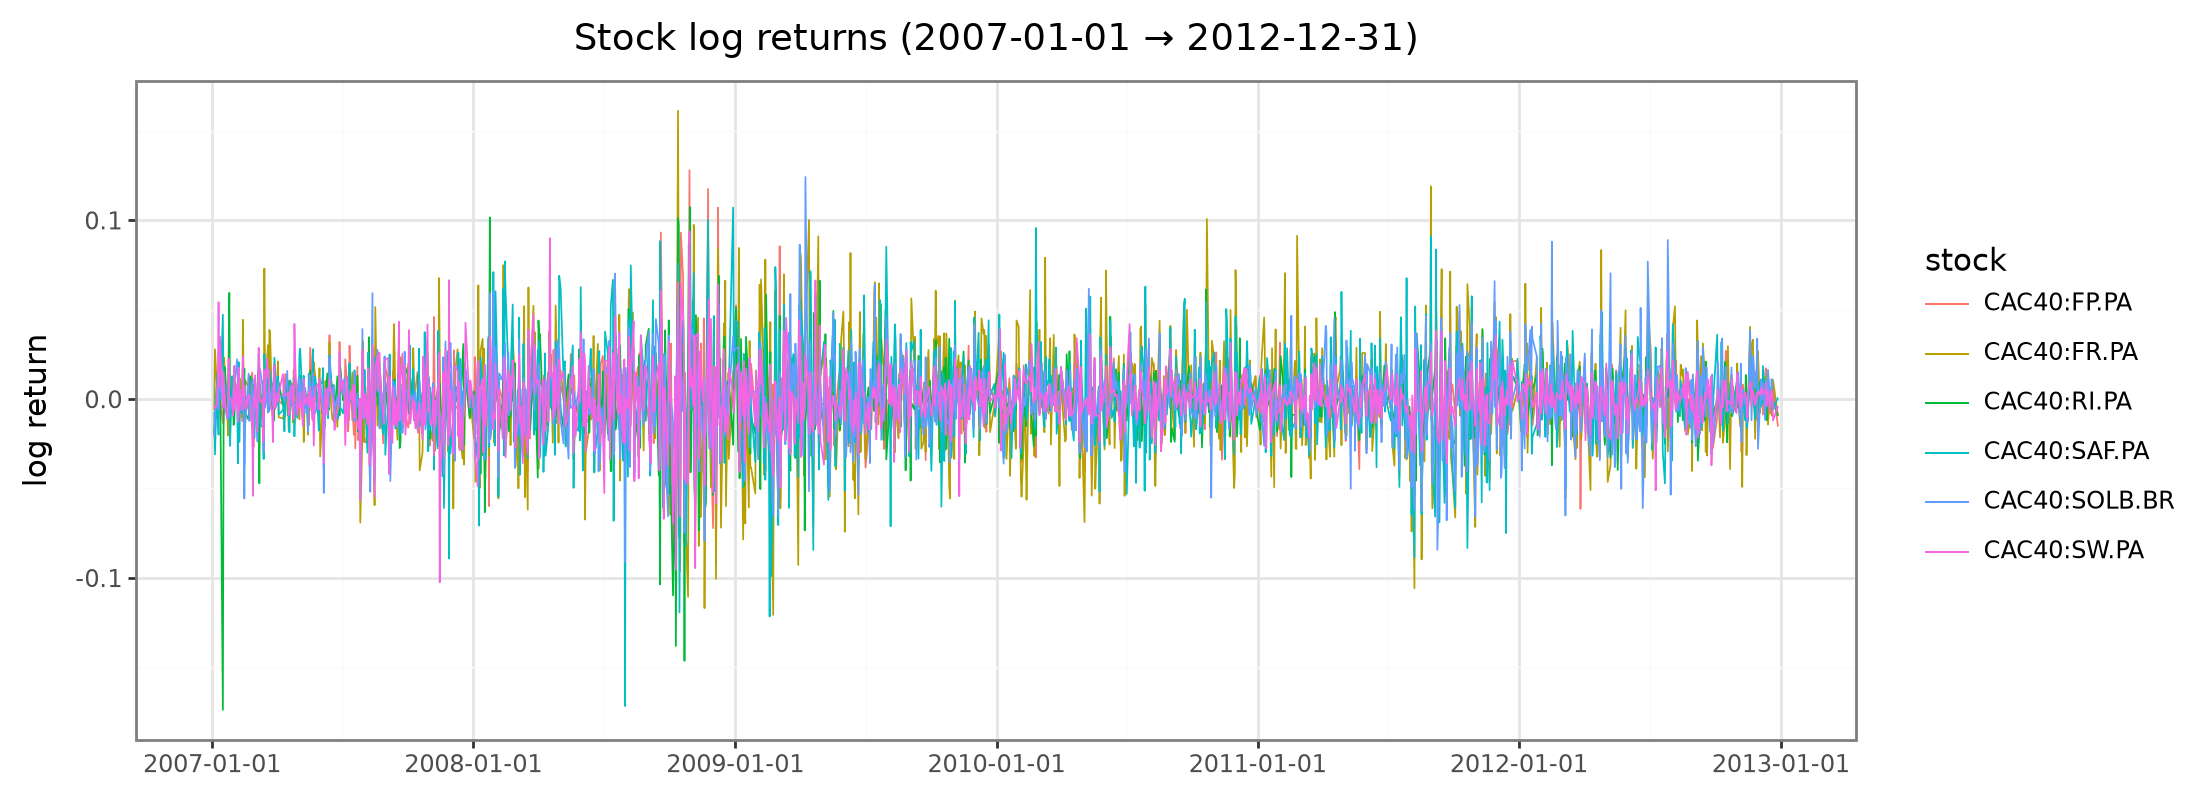

In [5]:
plot_tickers = tickers[:6]
long_plot = (
    wide.unpivot(index="date", on=plot_tickers, variable_name="stock", value_name="log_ret")
    .to_pandas()
)
long_plot["date"] = pd.to_datetime(long_plot["date"])

(
    ggplot(long_plot, aes("date", "log_ret", color="stock"))
    + geom_line(size=0.35)
    + theme_bw()
    + theme(figure_size=(11, 4))
    + labs(title=f"Stock log returns ({START} → {END})", x="", y="log return")
)

## 4. Feature engineering

Per-stock **log returns** plus 20-day rolling **vol** → full feature matrix for
gulfstream (stationary inputs; no price levels).


In [6]:
vol_window = 20
vol_cols: list[str] = []
features_df = wide.select("date")
for c in tickers:
    v = f"{c}_vol"
    vol_cols.append(v)
    features_df = features_df.with_columns(
        wide[c].alias(c),
        wide[c].rolling_std(vol_window).alias(v),
    )

features_df = features_df.drop_nulls()
print("features:", features_df.shape, "n_feat:", frames.n_features(features_df))
print(f"  returns: {len(tickers)}  vol: {len(vol_cols)}")
print(f"date range: {features_df['date'].min()} → {features_df['date'].max()}")
plot_cols = tickers[:3]
features_df.head(3)


features: (1388, 85) n_feat: 84
  returns: 42  vol: 42
date range: 2007-02-01 00:00:00 → 2012-12-28 00:00:00


date,CAC40:FP.PA,CAC40:FP.PA_vol,CAC40:FR.PA,CAC40:FR.PA_vol,CAC40:RI.PA,CAC40:RI.PA_vol,CAC40:SAF.PA,CAC40:SAF.PA_vol,CAC40:SOLB.BR,CAC40:SOLB.BR_vol,CAC40:SW.PA,CAC40:SW.PA_vol,CAC40:URW.AS,CAC40:URW.AS_vol,DAX30:BAYN.DE,DAX30:BAYN.DE_vol,DAX30:BMW.DE,DAX30:BMW.DE_vol,DAX30:DAI.DE,DAX30:DAI.DE_vol,DAX30:FME.DE,DAX30:FME.DE_vol,DAX30:HEI.DE,DAX30:HEI.DE_vol,DAX30:LIN.DE,DAX30:LIN.DE_vol,DAX30:SAP.DE,DAX30:SAP.DE_vol,FTSE100:CPG.L,FTSE100:CPG.L_vol,FTSE100:CRDA.L,FTSE100:CRDA.L_vol,FTSE100:CRH.L,FTSE100:CRH.L_vol,FTSE100:FERG.L,FTSE100:FERG.L_vol,…,HSI50:X0012.HK_vol,HSI50:X0027.HK,HSI50:X0027.HK_vol,HSI50:X0688.HK,HSI50:X0688.HK_vol,HSI50:X1044.HK,HSI50:X1044.HK_vol,HSI50:X1109.HK,HSI50:X1109.HK_vol,MIB40:BAMI.MI,MIB40:BAMI.MI_vol,MIB40:BZU.MI,MIB40:BZU.MI_vol,MIB40:EXO.MI,MIB40:EXO.MI_vol,MIB40:FCA.MI,MIB40:FCA.MI_vol,MIB40:ISP.MI,MIB40:ISP.MI_vol,MIB40:JUVE.MI,MIB40:JUVE.MI_vol,MIB40:MB.MI,MIB40:MB.MI_vol,SP500:ABC,SP500:ABC_vol,SP500:ABMD,SP500:ABMD_vol,SP500:EQIX,SP500:EQIX_vol,SP500:MHK,SP500:MHK_vol,SP500:O,SP500:O_vol,SP500:ORLY,SP500:ORLY_vol,SP500:WM,SP500:WM_vol
datetime[μs],f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
2007-02-01 00:00:00,0.016276,0.010016,0.007113,0.01252,-0.012168,0.043458,0.010929,0.017731,0.016129,0.009934,0.018502,0.016039,0.008235,0.010285,0.004415,0.015326,0.008087,0.011521,0.012096,0.014078,0.018559,0.011741,-0.004627,0.006241,0.012816,0.012884,0.011512,0.026356,0.006574,0.011375,0.020097,0.015611,0.018331,0.009672,0.025469,0.013426,…,0.019055,0.005038,0.017044,-0.015178,0.033448,-0.016529,0.021624,-0.018019,0.03616,0.002513,0.009614,0.006882,0.010753,0.035456,0.01764,0.022006,0.013959,0.003452,0.010437,0.007194,0.015652,-0.002289,0.006515,-0.000191,0.019674,-0.02687,0.015828,-0.010402,0.017991,0.040074,0.017717,0.007615,0.010413,-0.007187,0.018069,-0.007665,0.010636
2007-02-02 00:00:00,0.0,0.009033,0.009602,0.012284,0.0,0.043361,-0.003812,0.017651,0.011728,0.008935,-0.006437,0.016141,0.026304,0.011636,-0.000661,0.01524,0.001271,0.01116,0.005788,0.013997,0.000287,0.011689,0.003116,0.005817,-0.015009,0.013496,-0.007285,0.026333,0.0,0.010004,0.005168,0.015695,0.015448,0.010094,-0.004447,0.012781,…,0.019732,0.003762,0.016913,-0.009457,0.030218,0.0,0.021394,0.025643,0.034166,0.009992,0.009509,0.003196,0.010766,0.014407,0.017598,0.008784,0.01381,-0.002587,0.00993,-0.006686,0.015754,0.001713,0.006567,-0.000764,0.019733,0.013181,0.015388,-0.000481,0.017459,0.012741,0.0177,0.0,0.010348,-0.001733,0.018107,0.004236,0.010176
2007-02-05 00:00:00,0.006626,0.0087,0.000842,0.01114,0.0,0.043357,0.003268,0.01583,0.022236,0.009721,0.008269,0.015903,0.037722,0.013428,-0.007522,0.014997,-0.006371,0.011335,-0.00558,0.014075,-0.007785,0.011236,0.000357,0.005814,-0.000244,0.012708,-0.004792,0.026206,0.000821,0.010008,0.065817,0.021648,0.007949,0.010139,0.002968,0.012597,…,0.018087,0.025943,0.016833,-0.058697,0.031118,0.007116,0.020718,-0.016593,0.03422,-0.004983,0.009762,0.000911,0.010285,-0.018771,0.01821,-0.005262,0.013893,-0.007803,0.009891,-0.021914,0.016677,-0.003434,0.006324,0.003243,0.019276,-0.005529,0.01504,-0.005668,0.017141,-0.010296,0.017484,0.003786,0.00699,-0.022506,0.018686,0.011558,0.009465


## 5. Feature snapshot


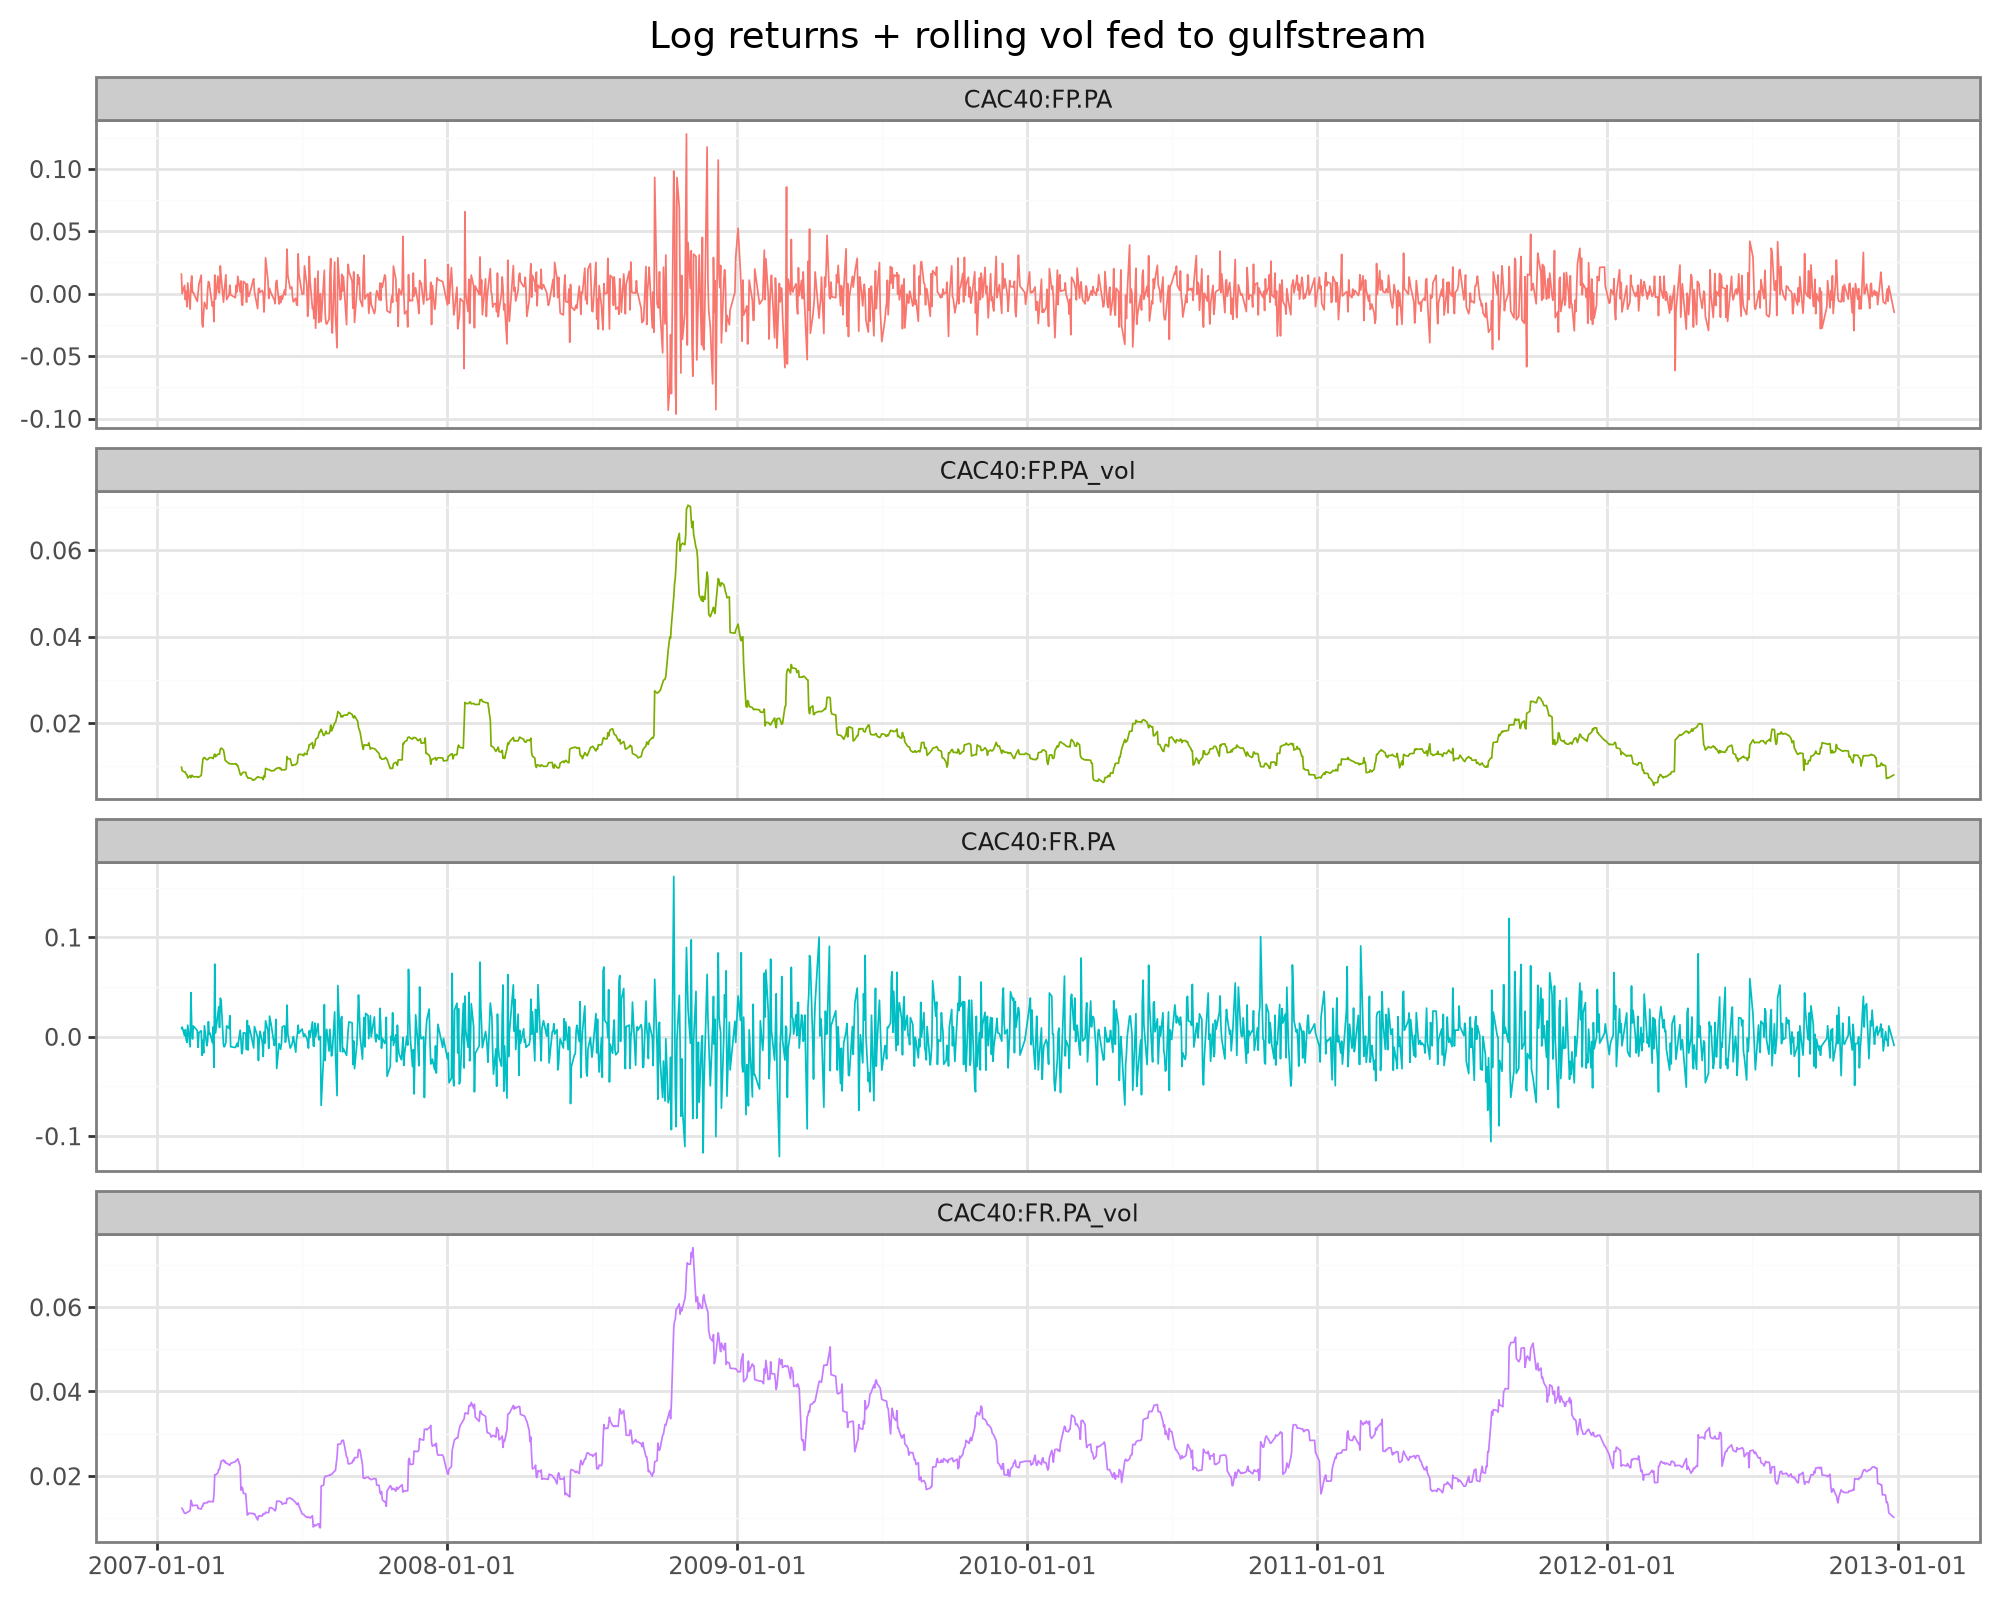

In [7]:
viz_cols = tickers[:2] + vol_cols[:2]
viz_cols = [c for c in viz_cols if c in features_df.columns]
long_f = (
    features_df.select(["date", *viz_cols])
    .unpivot(index="date", on=viz_cols, variable_name="series", value_name="value")
    .to_pandas()
)
long_f["date"] = pd.to_datetime(long_f["date"])

(
    ggplot(long_f, aes("date", "value", color="series"))
    + geom_line(size=0.35)
    + facet_wrap("~series", scales="free_y", ncol=1)
    + theme_bw()
    + theme(figure_size=(10, 2.0 * len(viz_cols)), legend_position="none")
    + labs(title="Log returns + rolling vol fed to gulfstream", x="", y="")
)


## 6. Shared helpers (public API)

Equity defaults use a slightly looser MMD gate so breaks survive in this window.


In [8]:
import copy
from IPython.display import Image, display

from gulfstream import (
    plot_regimes,
    refine_regimes,
    regime_intervals,
    run_single_segmentation,
    seed_regimes_from_results,
)
from gulfstream.common import frames, utils
from gulfstream.common.options import (
    ClassicalDetector,
    DetectionBackend,
    SearchMethod,
    StatTest,
)
from gulfstream.metrics.evaluation import (
    adjusted_rand_index,
    breakpoint_precision_recall_f1,
    covering_metric,
)


def load_core_params(img_dir: Path) -> dict:
    """Validated Graph 1 core params with notebook-friendly metrics."""
    params = utils.read_config_yaml(
        str(ROOT / "config" / "graph1" / "default_core.yaml"),
        img_dir=str(img_dir),
        log_dir=str(ROOT / "outputs" / "logs"),
    )
    params["test_num"] = 0
    params["metrics"]["mode"] = "display_and_write"
    params["metrics"]["plot"] = True
    params["metrics"]["dir"] = str(img_dir)
    params["metrics"]["image_dir"] = str(img_dir)
    params["robustness"]["enabled"] = False
    params["stability"]["enabled"] = False
    return params


def with_dimred(params: dict, method: str) -> dict:
    out = copy.deepcopy(params)
    method = method.lower()
    out["algo"]["dimred"] = [method]
    if method == "kpca":
        out["algo"]["kpca_kernel_params"] = [{"kernel": "rbf", "gamma": "median"}]
    elif method == "dmd":
        out["algo"]["dmd_stride"] = [5]
        out["algo"]["dmd_rolling_window"] = [20]
    elif method == "ica":
        out["algo"]["rank"] = [3]
        out["algo"]["rank_selection_method"] = ["user_specified"]
        out["algo"]["random_state"] = [42]
        out["algo"]["ica_max_iter"] = [200]
    elif method == "fpca":
        out["algo"]["rank_selection_method"] = ["explained_variance"]
        out["algo"]["threshold"] = [0.9]
        out["algo"]["fpca_smooth_window"] = [3]
    elif method == "nelson_siegel":
        out["algo"]["ns_lambda"] = [0.0609]
    elif method == "dynamic_factor":
        out["algo"]["rank"] = [2]
        out["algo"]["rank_selection_method"] = ["user_specified"]
        out["algo"]["factor_order"] = [1]
        out["algo"]["df_maxiter"] = [30]
    elif method != "pca":
        raise ValueError(f"Unsupported dimred: {method}")
    return out


def with_search(params: dict, method, **algo_extras) -> dict:
    out = copy.deepcopy(params)
    out["algo"]["search_method"] = [str(method)]
    for k, v in algo_extras.items():
        out["algo"][k] = v if isinstance(v, list) else [v]
    return out


def with_test(params: dict, choice) -> dict:
    out = copy.deepcopy(params)
    out["test"]["choice"] = [str(choice)]
    return out


def with_ess_window(
    params: dict,
    *,
    ess_fraction: float = 0.25,
    min_window: int = 20,
    max_window: int = 100,
) -> dict:
    out = copy.deepcopy(params)
    out["test"]["window"] = [
        {
            "method": "ess",
            "ess_fraction": ess_fraction,
            "min_window": min_window,
            "max_window": max_window,
        }
    ]
    return out


def with_classical(
    params: dict,
    detector,
    *,
    regimes: int | None = 3,
    min_regime_length: int = 20,
    **algo_extras,
) -> dict:
    """Hard-label classical backend (former --mode legacy)."""
    out = copy.deepcopy(params)
    out["algo"]["detection_backend"] = [str(DetectionBackend.CLASSICAL)]
    out["algo"]["regime_detection_algorithm"] = [str(detector)]
    out["algo"]["dimred"] = ["raw"]
    out["algo"]["feature_map_approx_method"] = ["raw"]
    out["algo"]["post_processing_method"] = ["majority_voting"]
    out["algo"]["min_regime_length"] = [min_regime_length]
    out["algo"]["include_last_regime"] = [True]
    if regimes is not None:
        out["algo"]["regimes"] = [regimes]
    for k, v in algo_extras.items():
        out["algo"][k] = v if isinstance(v, list) else [v]
    return out


def with_model_dimred(params: dict, method, *, regimes: int = 3) -> dict:
    """Use classical models as soft embeddings into kernel_ruptures."""
    out = copy.deepcopy(params)
    out["algo"]["detection_backend"] = [str(DetectionBackend.KERNEL_RUPTURES)]
    out["algo"]["dimred"] = [str(method)]
    out["algo"]["regimes"] = [regimes]
    return out


def with_tft(
    params: dict,
    *,
    rank: int = 8,
    encoder_length: int = 20,
    prediction_length: int = 5,
    max_epochs: int = 1,
    batch_size: int = 16,
    mode: str = "multivariate",
) -> dict:
    """TFT attention embeddings → kernel_ruptures (smoke-friendly defaults)."""
    out = copy.deepcopy(params)
    out["algo"]["detection_backend"] = [str(DetectionBackend.KERNEL_RUPTURES)]
    out["algo"]["dimred"] = ["tft"]
    out["algo"]["rank"] = [rank]
    out["algo"]["rank_selection_method"] = ["user_specified"]
    out["algo"]["tft_encoder_length"] = [encoder_length]
    out["algo"]["tft_prediction_length"] = [prediction_length]
    out["algo"]["tft_max_epochs"] = [max_epochs]
    out["algo"]["tft_batch_size"] = [batch_size]
    out["algo"]["tft_mode"] = [mode]
    out["algo"]["num_features"] = [30]
    out["algo"]["depth"] = [1]
    return out


def summarize(res, label: str, df: pl.DataFrame) -> None:
    dates = frames.dates_series(df).to_list()
    print(f"[{label}] kept={res.bkpts}  invalid={res.invalid_bkpts}")
    for b in res.bkpts:
        print(f"  bkpt {b} → {dates[b]}")


def run_g1(
    df: pl.DataFrame,
    params: dict,
    label: str,
    plot_vars: list[str],
    *,
    return_fig: bool = False,
):
    """Graph 1 via public single-pass API.

    Returns ``proc`` by default. Pass ``return_fig=True`` to also get the plotnine
    ggplot (without auto-displaying it) for explicit notebook inspection.
    """
    print(
        f"=== Graph 1 · {label} · backend={params['algo'].get('detection_backend')} "
        f"dimred={params['algo']['dimred']} "
        f"detector={params['algo'].get('regime_detection_algorithm')} "
        f"search={params['algo'].get('search_method')} "
        f"test={params['test'].get('choice')} ==="
    )
    proc = run_single_segmentation(df, params)
    summarize(proc, label, df)
    metrics = params.get("metrics", {})
    img_dir = metrics.get("image_dir") or metrics.get("dir")
    if return_fig:
        plot_mode = "write" if img_dir else "display"
        plot_emit = bool(img_dir)
    else:
        plot_mode = "display_and_write" if img_dir else "display"
        plot_emit = True
    fig = plot_regimes(
        df,
        proc,
        variables=plot_vars[:2],
        title=f"Graph 1 · {label}",
        mode=plot_mode,
        img_dir=str(img_dir) if img_dir else None,
        emit=plot_emit,
    )
    if return_fig:
        return proc, fig
    return proc


def run_g2(
    df: pl.DataFrame,
    params: dict,
    seed_res,
    out_dir: Path,
    label: str,
    plot_vars: list[str],
    *,
    max_iter: int = 3,
    threshold: float = 1e-6,
    score_method: str = "mse_to_mean",
    score: dict | None = None,
    return_figs: bool = False,
):
    """Graph 2 via refine_regimes, seeded from a Graph 1 SegmentResults.

    Returns ``out_dir`` by default. Pass ``return_figs=True`` to also get
    ``refined`` and a ``figs`` dict mapping string keys to plotnine ggplots
    (``retrain_iteration_*`` heatmaps + ``regime``).
    """
    out_dir.mkdir(parents=True, exist_ok=True)
    g2 = copy.deepcopy(params)
    g2["metrics"]["dir"] = str(out_dir)
    g2["metrics"]["image_dir"] = str(out_dir)
    g2["metrics"]["mode"] = "display_and_write"
    g2["metrics"]["plot"] = True
    g2["retrain"] = {
        "interactive": False,
        "features": ["__auto__"],
        "num_worst_features": min(5, frames.n_features(df)),
        "threshold": threshold,
        "max_iter": max_iter,
        "score_method": score_method,
        "score": dict(score or {}),
        "regimes_df": None,
    }
    print(f"=== Graph 2 · {label} · score_method={score_method} · seeding from Graph 1 ===")
    print(seed_regimes_from_results(df, seed_res).to_dicts())
    refined = refine_regimes(df, g2, seed=seed_res)
    figs: dict = {}
    if refined is not None:
        summarize(refined, f"{label} Graph 2", df)
        if return_figs:
            figs.update(getattr(refined, "plots", None) or {})
            figs["regime"] = plot_regimes(
                df,
                refined,
                variables=plot_vars[:2],
                title=f"Graph 2 · {label}",
                mode="write",
                img_dir=str(out_dir),
                emit=False,
            )
        else:
            plot_regimes(
                df,
                refined,
                variables=plot_vars[:2],
                title=f"Graph 2 · {label}",
                mode="display",
            )
    if not return_figs:
        pngs = sorted(out_dir.rglob("retrain_iteration_*.png"))[:6]
        print(f"Graph 2 artifacts under {out_dir}")
        for p in pngs:
            print(" ", p.relative_to(out_dir))
            try:
                display(Image(filename=str(p)))
            except Exception as exc:
                print("  (could not display)", exc)
    else:
        print(f"Graph 2 artifacts under {out_dir} ({len(figs)} plotnine figure(s))")
        print(" fig keys:", sorted(figs))
    if return_figs:
        return out_dir, refined, figs
    return out_dir


print("Helpers ready: run_g1/g2, with_dimred/search/test/ess/classical/model_dimred/tft")
print("Enums:", list(DetectionBackend), list(ClassicalDetector)[:4], "...")

Helpers ready: run_g1/g2, with_dimred/search/test/ess/classical/model_dimred/tft
Enums: [<DetectionBackend.KERNEL_RUPTURES: 'kernel_ruptures'>, <DetectionBackend.CLASSICAL: 'classical'>] [<ClassicalDetector.BAYESIAN_GMM: 'bayesian_gmm'>, <ClassicalDetector.HMM: 'hmm'>, <ClassicalDetector.KMEANS: 'kmeans'>, <ClassicalDetector.HDBSCAN: 'hdbscan'>] ...


In [14]:
def equity_params(img_dir: Path) -> dict:
    params = load_core_params(img_dir)
    params["metrics"]["features_to_plot"] = plot_cols
    # Returns-based equity panels: shorter min regime than log-price levels (was 20)
    params["algo"]["min_regime_length"] = [20]
    params["algo"]["depth"] = [4]
    params["test"]["significance_level"] = [0.2]
    params["test"]["window"] = [{"method": "user_specified", "window": 60}]
    params["test"]["sample_size"] = [{"method": "user_specified", "num_samples": 60}]
    return params

---
# Part A — PCA (baseline)


## A.1 Graph 1 (PCA)


=== Graph 1 · PCA · backend=['kernel_ruptures'] dimred=['pca'] detector=[] search=['pelt'] test=['mmd_no_ts'] ===
[PCA] kept=[20, 45, 70, 105, 175, 670, 1060]  invalid=[1320]
  bkpt 20 → 2007-03-05 00:00:00
  bkpt 45 → 2007-04-12 00:00:00
  bkpt 70 → 2007-05-21 00:00:00
  bkpt 105 → 2007-07-16 00:00:00
  bkpt 175 → 2007-10-30 00:00:00
  bkpt 670 → 2009-12-01 00:00:00
  bkpt 1060 → 2011-07-26 00:00:00


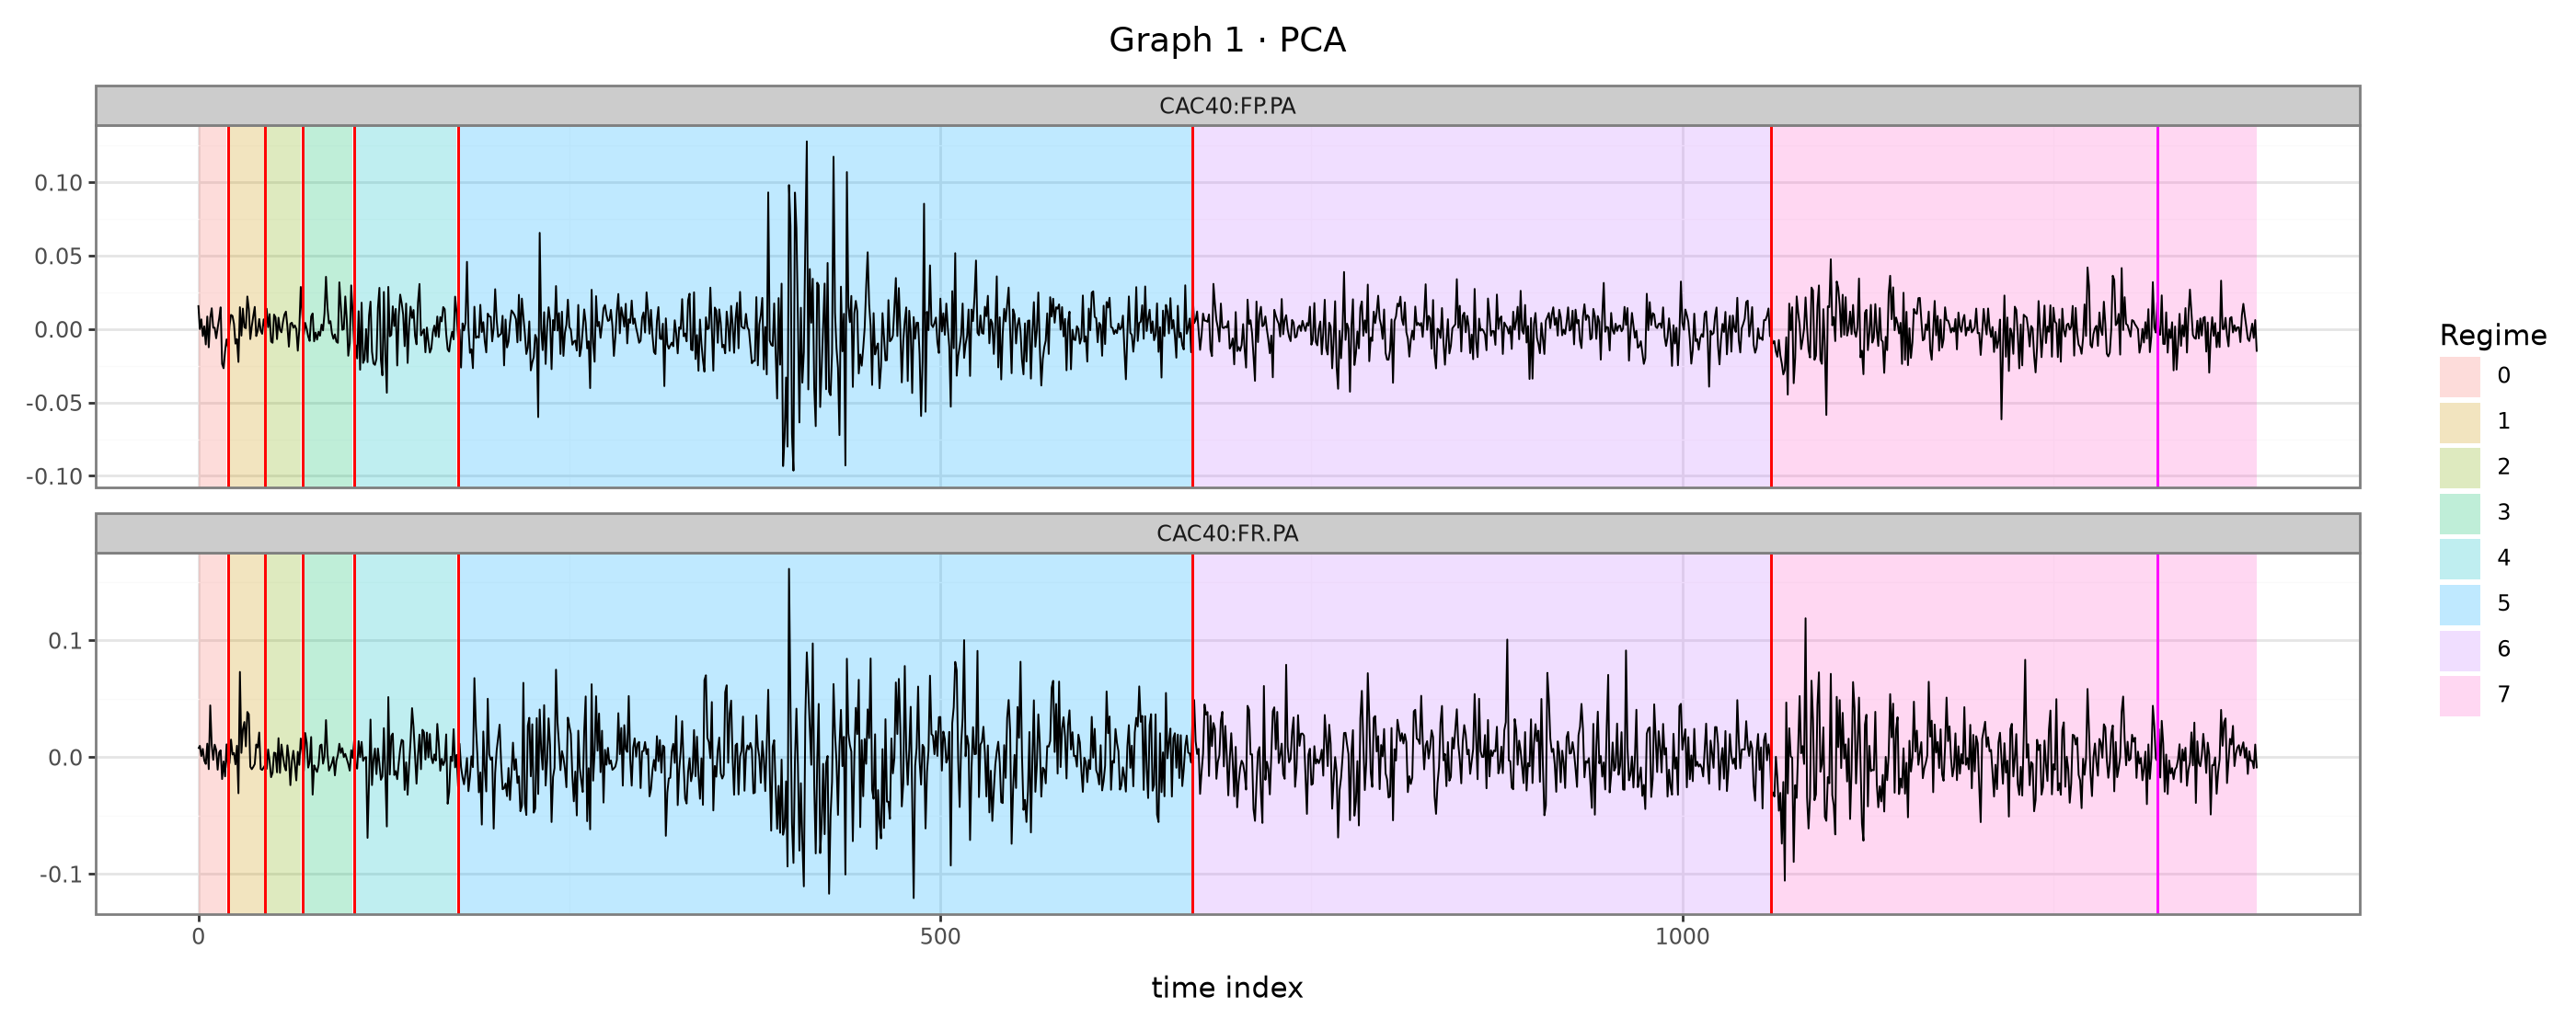

In [15]:
params_pca = with_dimred(equity_params(OUT_DIR / "pca"), "pca")
proc_pca, fig_pca = run_g1(features_df, params_pca, "PCA", plot_cols, return_fig=True)
fig_pca

## A.2 Graph 2 (seeded from PCA)

Auto-retrain via a feature×regime **score heatmap** (default `mse_to_mean` / L2).
Part L swaps `retrain.score_method` for panel-friendly alternatives.


INFO [gulfstream.common.logging] Logging to d:\Code\gulfstream\outputs\logs\gulfstream_20260805_112901.log
INFO [gulfstream.pipelines.graph2.reporting] Generating L2 error matrix.


=== Graph 2 · PCA · score_method=mse_to_mean · seeding from Graph 1 ===
[{'Start': datetime.datetime(2007, 2, 1, 0, 0), 'End': datetime.datetime(2012, 12, 28, 0, 0), 'Regime': 0, 'Hierarchy Level of End': 0}]
Current breakpoint hierarchy: 
{}


INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\pca\graph2\bkpt_tests_20260805_112901\0\retrain_iteration_0_avg_feature_L2.png
INFO [gulfstream.pipelines.graph2.reporting] Saved error matrix to d:\Code\gulfstream\outputs\notebooks\equity\pca\graph2\bkpt_tests_20260805_112901\0/retrain_iteration_0_avg_feature_L2.png.


Retraining in regime 0 with features DAX30, MIB40, HSI50, SP500, CAC40.


INFO [gulfstream.metrics.writers] Regime stats: processed bkpts=[] invalid=[] (raw bkpts=[])
INFO [gulfstream.pipelines.graph2.reporting] Producing all explainability and visualization tools.


Done retraining in regime 0.
Failed to find a breakpoint in the highest error regime. Quitting.


INFO [gulfstream.common.plotting] Saved regime plot to d:\Code\gulfstream\outputs\notebooks\equity\pca\graph2\bkpt_tests_20260805_112901\0\02_regime_plot.png
INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\pca\graph2\bkpt_tests_20260805_112901\0\04_avg_L2.png


<ggplot: (1400 x 839)>
<ggplot: (400 x 325)>


INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\pca\graph2\bkpt_tests_20260805_112901\0\05_aggregated_L2.png
INFO [gulfstream.metrics.insights] Fewer than 2 regimes; skipping distance/cluster insights.
INFO [gulfstream.detection.trees] Saved breakpoint tree to d:\Code\gulfstream\outputs\notebooks\equity\pca\graph2\bkpt_tests_20260805_112901\0\01_proc_bkpt_tree.png
d:\Code\gulfstream\src\gulfstream\detection\trees.py:113: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
WARNING [gulfstream.metrics.explainability] Fewer than 2 regimes; skipping explainability trees.
INFO [gulfstream.pipelines.graph2.loop] Targeted retrain done. Outputs in ..\outputs\notebooks\equity\pca\graph2\bkpt_tests_20260805_112901


<ggplot: (400 x 300)>
[PCA Graph 2] kept=[]  invalid=[]
<ggplot: (1400 x 560)>
Graph 2 artifacts under d:\Code\gulfstream\outputs\notebooks\equity\pca\graph2
  bkpt_tests_20260805_102935\0\retrain_iteration_0_avg_feature_L2.png


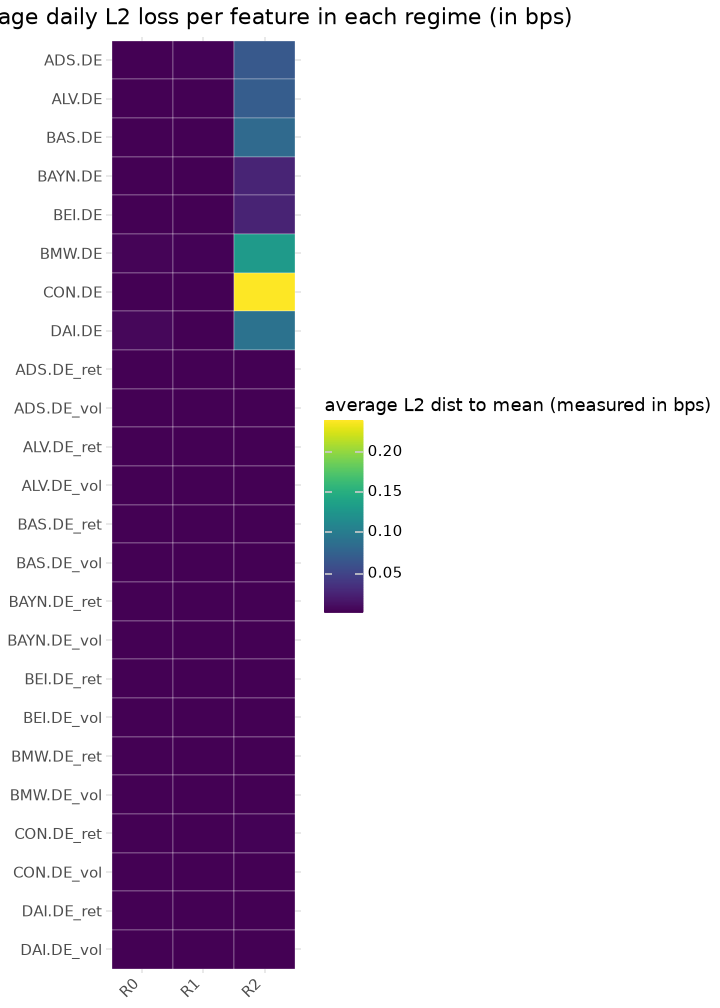

  bkpt_tests_20260805_102935\0\retrain_iteration_1_avg_feature_L2.png


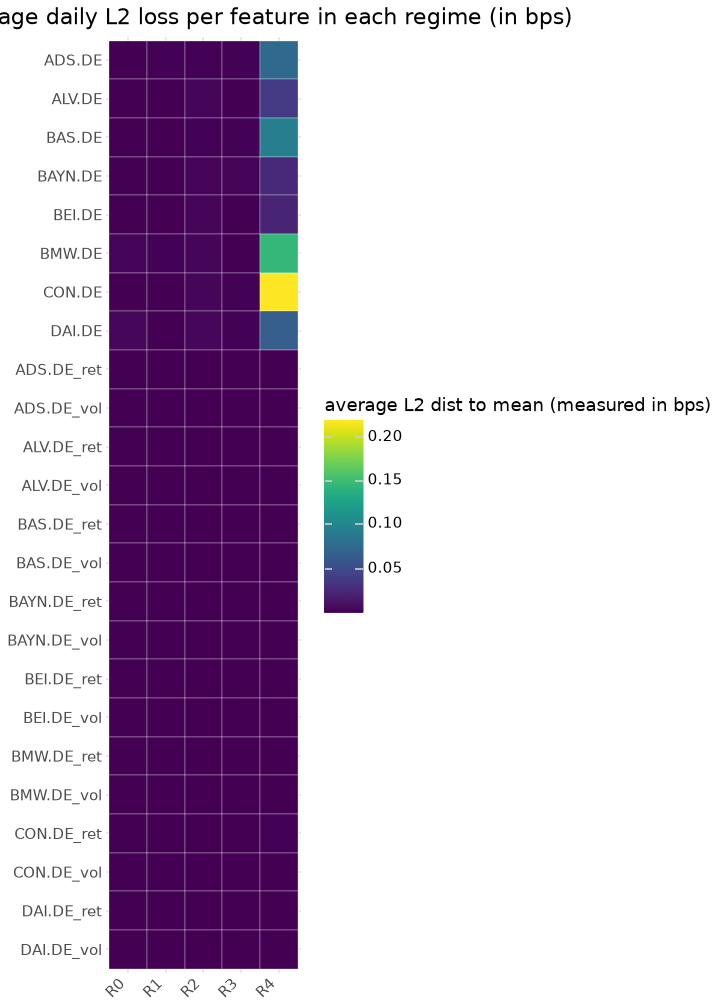

  bkpt_tests_20260805_102935\0\retrain_iteration_2_avg_feature_L2.png


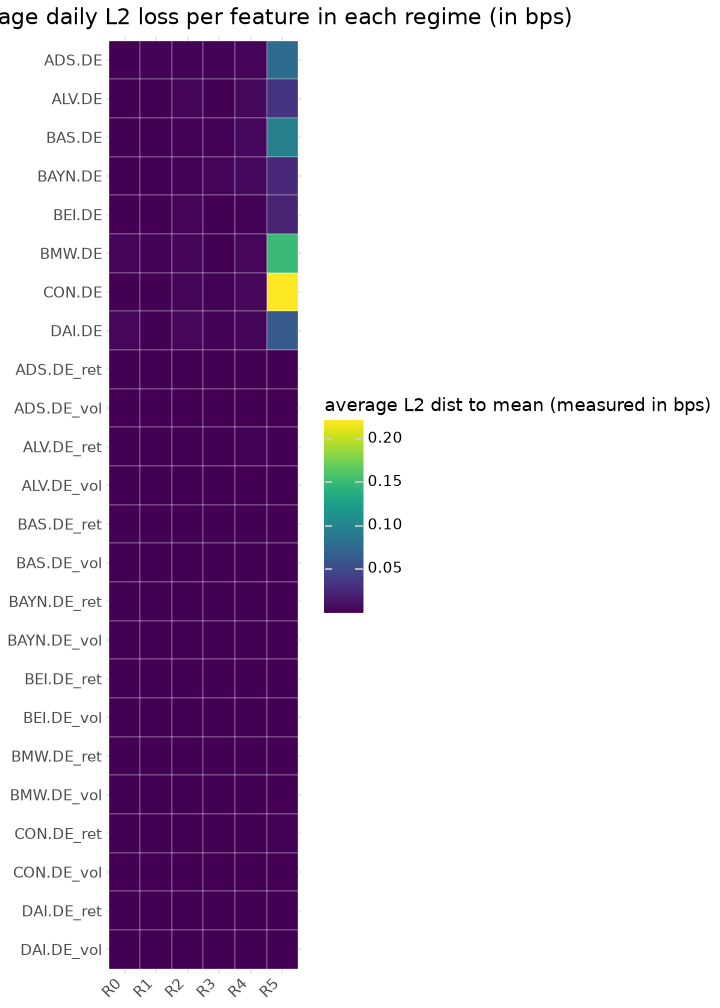

  bkpt_tests_20260805_102935\0\retrain_iteration_3_avg_feature_L2.png


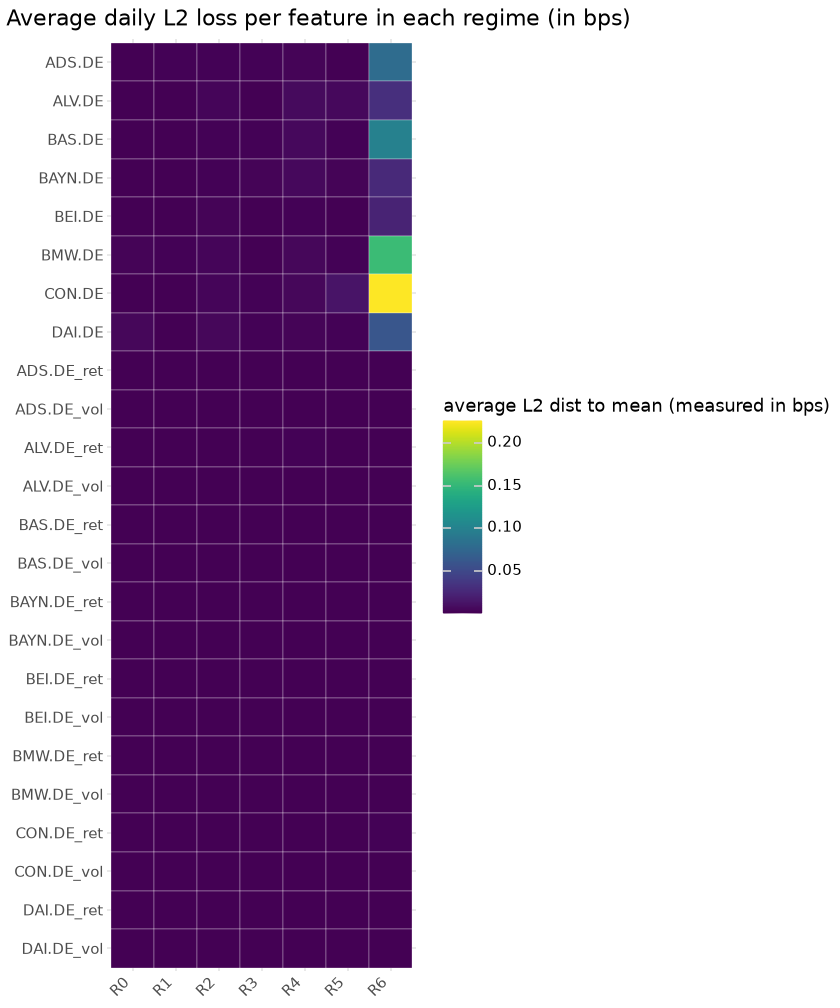

  bkpt_tests_20260805_112901\0\retrain_iteration_0_avg_feature_L2.png


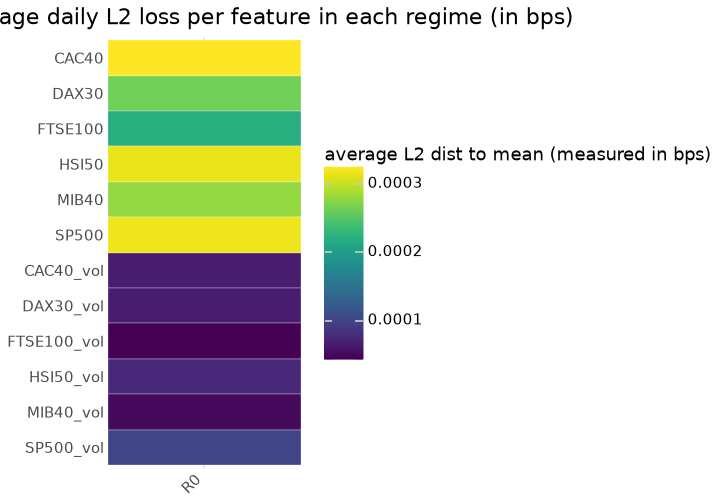

In [40]:
g2_pca_dir, proc_pca_g2, g2_pca_figs = run_g2(
    features_df,
    params_pca,
    proc_pca,
    OUT_DIR / "pca" / "graph2",
    "PCA",
    plot_cols,
    max_iter=3,
    return_figs=True,
)
g2_pca_figs["regime"]


---
# Part B — Kernel PCA


## B.1 Graph 1 (kPCA)


In [41]:
params_kpca = with_dimred(equity_params(OUT_DIR / "kpca"), "kpca")
proc_kpca = run_g1(features_df, params_kpca, "kPCA", plot_cols)


=== Graph 1 · kPCA · backend=['kernel_ruptures'] dimred=['kpca'] detector=[] search=['pelt'] test=['mmd_no_ts'] ===
[kPCA] kept=[]  invalid=[]
<ggplot: (1400 x 560)>


## B.2 Graph 2 (seeded from kPCA)


INFO [gulfstream.common.logging] Logging to d:\Code\gulfstream\outputs\logs\gulfstream_20260805_112903.log
INFO [gulfstream.pipelines.graph2.reporting] Generating L2 error matrix.


=== Graph 2 · kPCA · score_method=mse_to_mean · seeding from Graph 1 ===
[{'Start': datetime.datetime(2007, 2, 1, 0, 0), 'End': datetime.datetime(2012, 12, 28, 0, 0), 'Regime': 0, 'Hierarchy Level of End': 0}]
Current breakpoint hierarchy: 
{}


INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\kpca\graph2\bkpt_tests_20260805_112903\0\retrain_iteration_0_avg_feature_L2.png
INFO [gulfstream.pipelines.graph2.reporting] Saved error matrix to d:\Code\gulfstream\outputs\notebooks\equity\kpca\graph2\bkpt_tests_20260805_112903\0/retrain_iteration_0_avg_feature_L2.png.


Retraining in regime 0 with features DAX30, MIB40, HSI50, SP500, CAC40.


INFO [gulfstream.metrics.writers] Regime stats: processed bkpts=[] invalid=[] (raw bkpts=[])
INFO [gulfstream.pipelines.graph2.reporting] Producing all explainability and visualization tools.


Done retraining in regime 0.
Failed to find a breakpoint in the highest error regime. Quitting.


INFO [gulfstream.common.plotting] Saved regime plot to d:\Code\gulfstream\outputs\notebooks\equity\kpca\graph2\bkpt_tests_20260805_112903\0\02_regime_plot.png
INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\kpca\graph2\bkpt_tests_20260805_112903\0\04_avg_L2.png


<ggplot: (1400 x 839)>
<ggplot: (400 x 325)>


INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\kpca\graph2\bkpt_tests_20260805_112903\0\05_aggregated_L2.png
INFO [gulfstream.metrics.insights] Fewer than 2 regimes; skipping distance/cluster insights.
INFO [gulfstream.detection.trees] Saved breakpoint tree to d:\Code\gulfstream\outputs\notebooks\equity\kpca\graph2\bkpt_tests_20260805_112903\0\01_proc_bkpt_tree.png
d:\Code\gulfstream\src\gulfstream\detection\trees.py:113: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
WARNING [gulfstream.metrics.explainability] Fewer than 2 regimes; skipping explainability trees.
INFO [gulfstream.pipelines.graph2.loop] Targeted retrain done. Outputs in ..\outputs\notebooks\equity\kpca\graph2\bkpt_tests_20260805_112903


<ggplot: (400 x 300)>
[kPCA Graph 2] kept=[]  invalid=[]
<ggplot: (1400 x 560)>
Graph 2 artifacts under d:\Code\gulfstream\outputs\notebooks\equity\kpca\graph2
  bkpt_tests_20260805_103004\0\retrain_iteration_0_avg_feature_L2.png


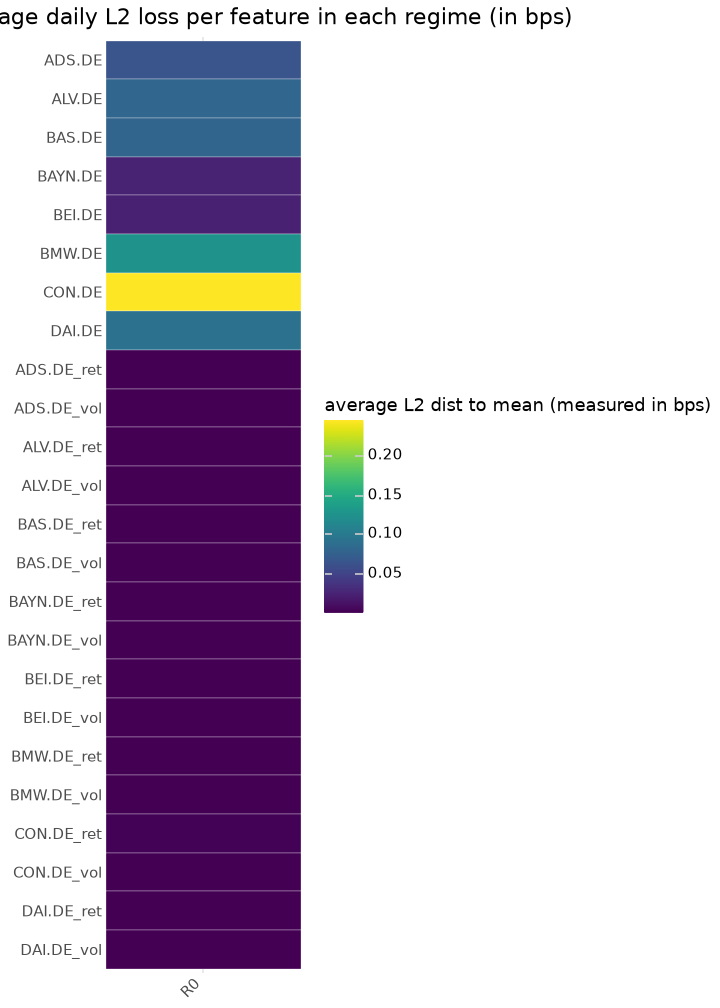

  bkpt_tests_20260805_103004\0\retrain_iteration_1_avg_feature_L2.png


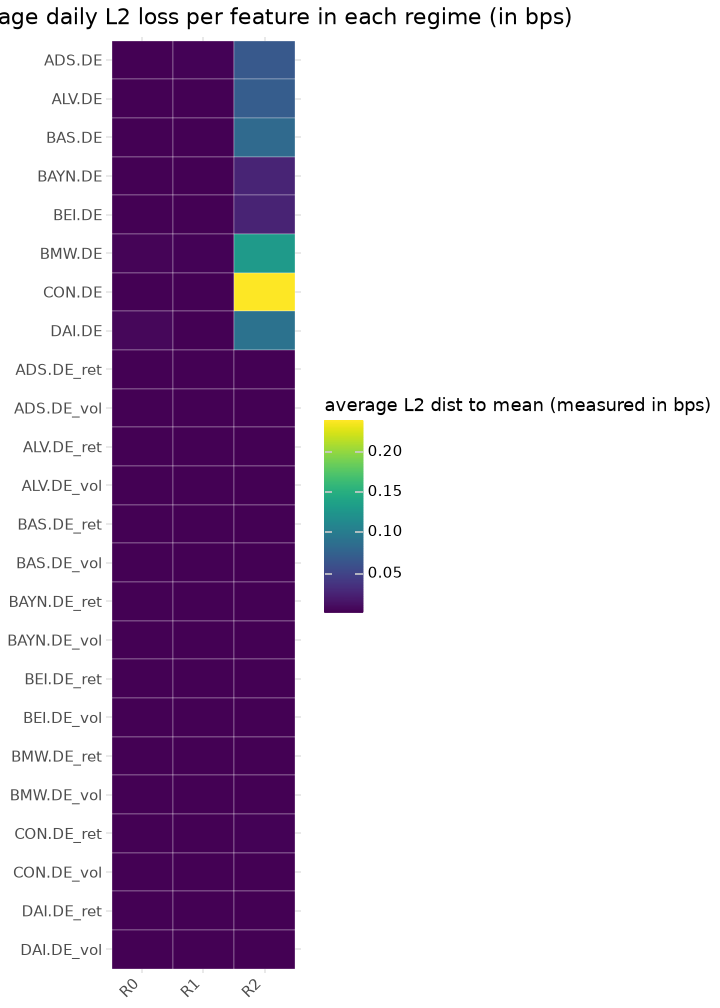

  bkpt_tests_20260805_103004\0\retrain_iteration_2_avg_feature_L2.png


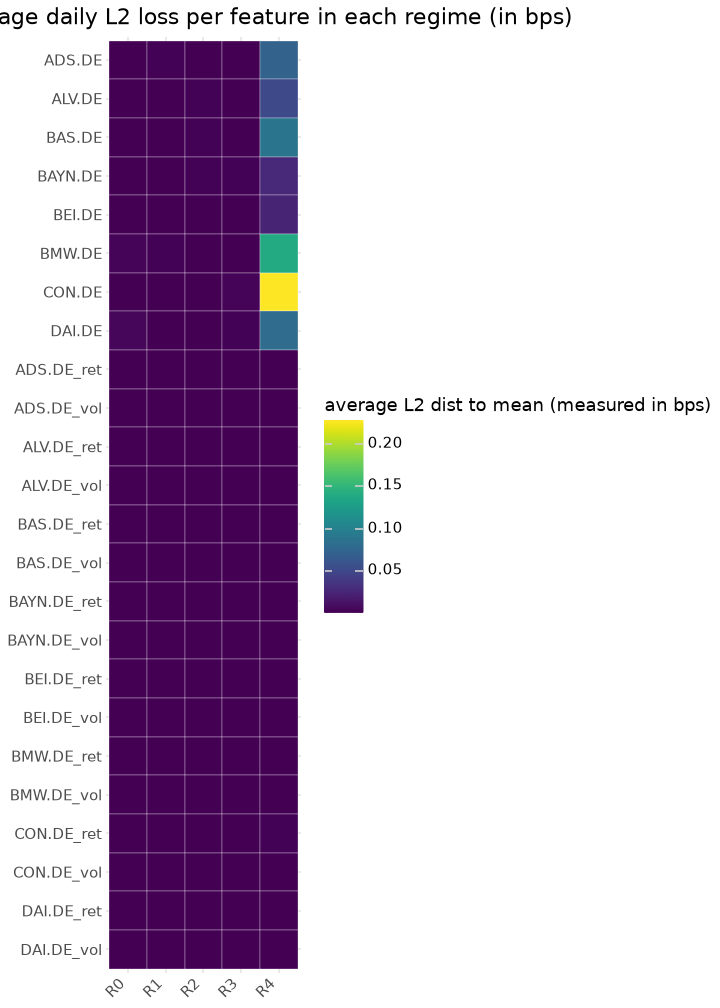

  bkpt_tests_20260805_103004\0\retrain_iteration_3_avg_feature_L2.png


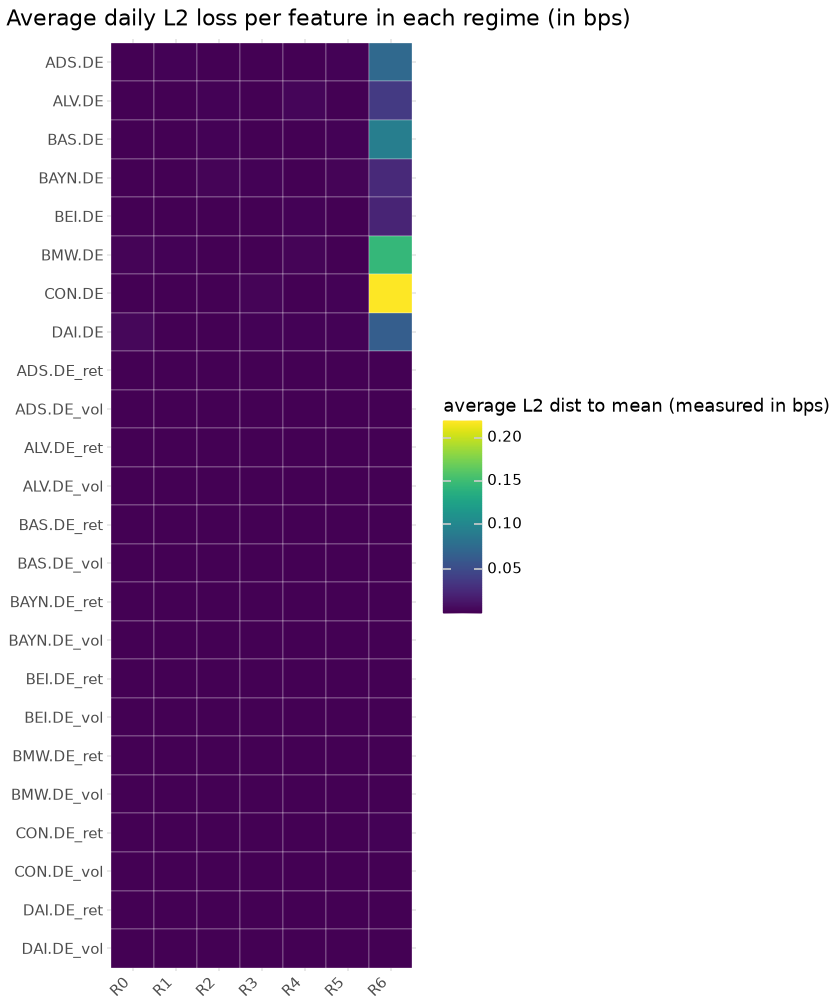

  bkpt_tests_20260805_112903\0\retrain_iteration_0_avg_feature_L2.png


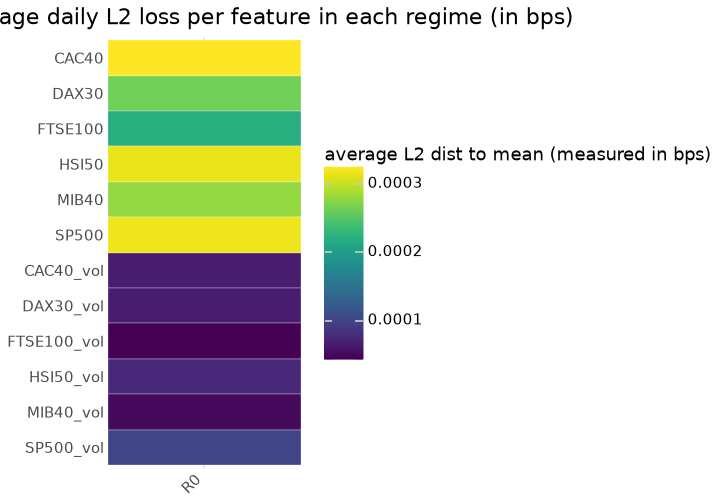

In [42]:
g2_kpca_dir = run_g2(
    features_df, params_kpca, proc_kpca, OUT_DIR / "kpca" / "graph2", "kPCA", plot_cols, max_iter=3
)


---
# Part C — DMD


## C.1 Graph 1 (DMD)


In [43]:
params_dmd = with_dimred(equity_params(OUT_DIR / "dmd"), "dmd")
proc_dmd = run_g1(features_df, params_dmd, "DMD", plot_cols)


=== Graph 1 · DMD · backend=['kernel_ruptures'] dimred=['dmd'] detector=[] search=['pelt'] test=['mmd_no_ts'] ===
[DMD] kept=[]  invalid=[10]
<ggplot: (1400 x 560)>


## C.2 Graph 2 (seeded from DMD)


INFO [gulfstream.common.logging] Logging to d:\Code\gulfstream\outputs\logs\gulfstream_20260805_112904.log
INFO [gulfstream.pipelines.graph2.reporting] Generating L2 error matrix.


=== Graph 2 · DMD · score_method=mse_to_mean · seeding from Graph 1 ===
[{'Start': datetime.datetime(2007, 2, 1, 0, 0), 'End': datetime.datetime(2012, 12, 28, 0, 0), 'Regime': 0, 'Hierarchy Level of End': 0}]
Current breakpoint hierarchy: 
{}


INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\dmd\graph2\bkpt_tests_20260805_112904\0\retrain_iteration_0_avg_feature_L2.png
INFO [gulfstream.pipelines.graph2.reporting] Saved error matrix to d:\Code\gulfstream\outputs\notebooks\equity\dmd\graph2\bkpt_tests_20260805_112904\0/retrain_iteration_0_avg_feature_L2.png.
INFO [gulfstream.dimred.classical.dmd] Calculating rank for DMD.
INFO [gulfstream.dimred.classical.dmd] Found rank 4 for DMD.


Retraining in regime 0 with features DAX30, MIB40, HSI50, SP500, CAC40.


INFO [gulfstream.metrics.writers] Regime stats: processed bkpts=[] invalid=[] (raw bkpts=[])
INFO [gulfstream.pipelines.graph2.reporting] Producing all explainability and visualization tools.


Done retraining in regime 0.
Failed to find a breakpoint in the highest error regime. Quitting.


INFO [gulfstream.common.plotting] Saved regime plot to d:\Code\gulfstream\outputs\notebooks\equity\dmd\graph2\bkpt_tests_20260805_112904\0\02_regime_plot.png
INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\dmd\graph2\bkpt_tests_20260805_112904\0\04_avg_L2.png


<ggplot: (1400 x 839)>
<ggplot: (400 x 325)>


INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\dmd\graph2\bkpt_tests_20260805_112904\0\05_aggregated_L2.png
INFO [gulfstream.metrics.insights] Fewer than 2 regimes; skipping distance/cluster insights.
INFO [gulfstream.detection.trees] Saved breakpoint tree to d:\Code\gulfstream\outputs\notebooks\equity\dmd\graph2\bkpt_tests_20260805_112904\0\01_proc_bkpt_tree.png
d:\Code\gulfstream\src\gulfstream\detection\trees.py:113: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
WARNING [gulfstream.metrics.explainability] Fewer than 2 regimes; skipping explainability trees.
INFO [gulfstream.pipelines.graph2.loop] Targeted retrain done. Outputs in ..\outputs\notebooks\equity\dmd\graph2\bkpt_tests_20260805_112904


<ggplot: (400 x 300)>
[DMD Graph 2] kept=[]  invalid=[]
<ggplot: (1400 x 560)>
Graph 2 artifacts under d:\Code\gulfstream\outputs\notebooks\equity\dmd\graph2
  bkpt_tests_20260805_103011\0\retrain_iteration_0_avg_feature_L2.png


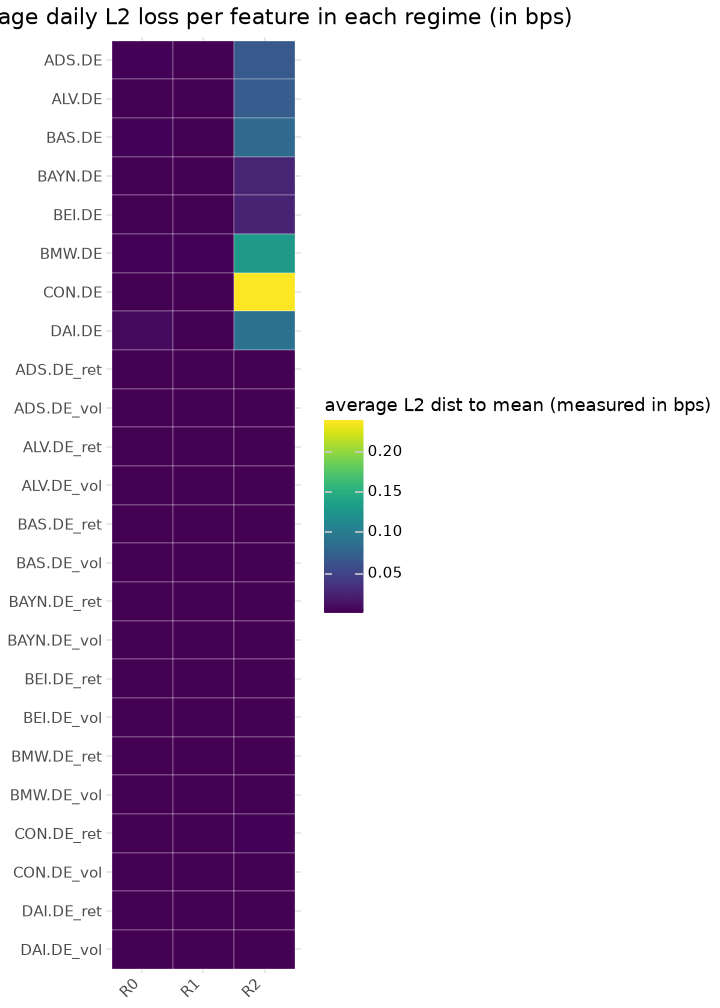

  bkpt_tests_20260805_103011\0\retrain_iteration_1_avg_feature_L2.png


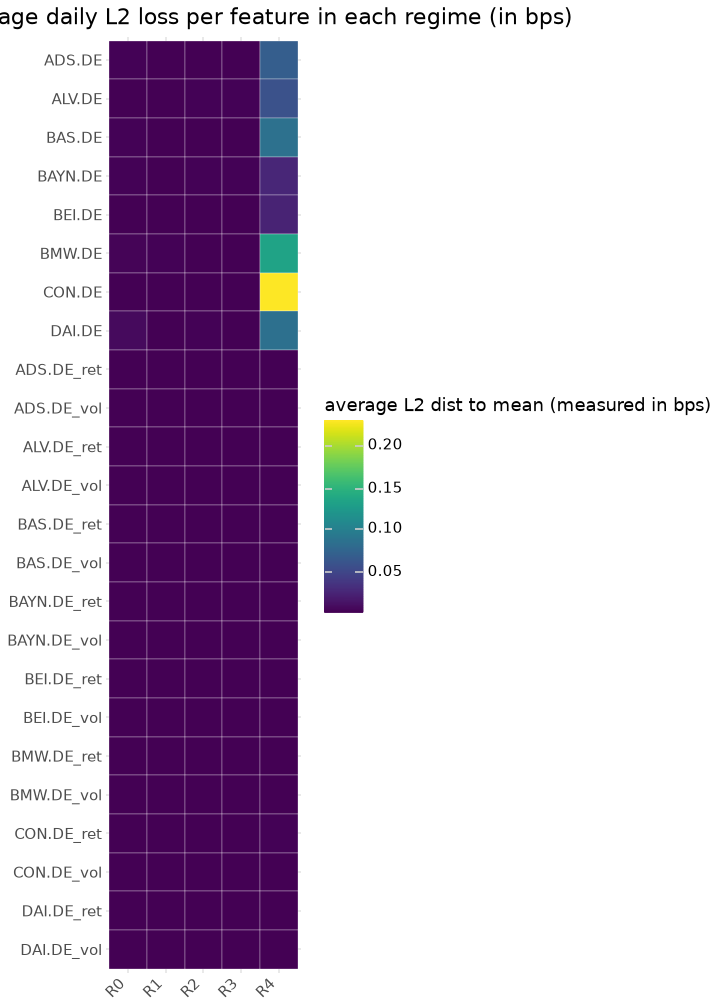

  bkpt_tests_20260805_103011\0\retrain_iteration_2_avg_feature_L2.png


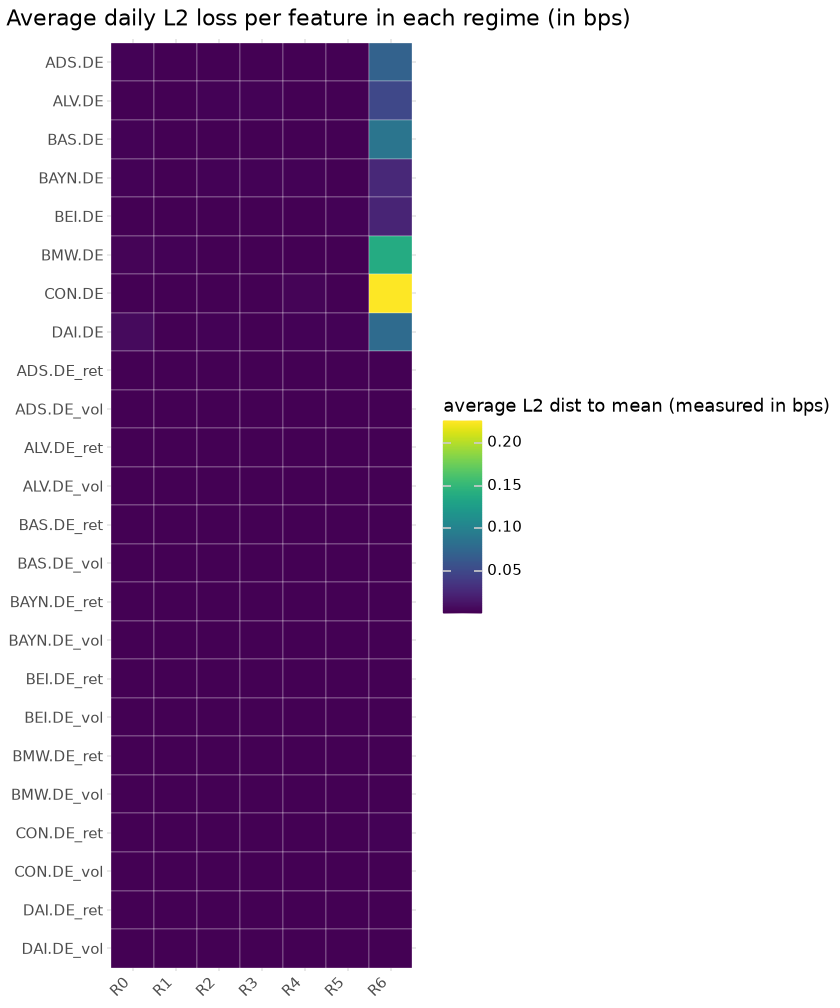

  bkpt_tests_20260805_103011\0\retrain_iteration_3_avg_feature_L2.png


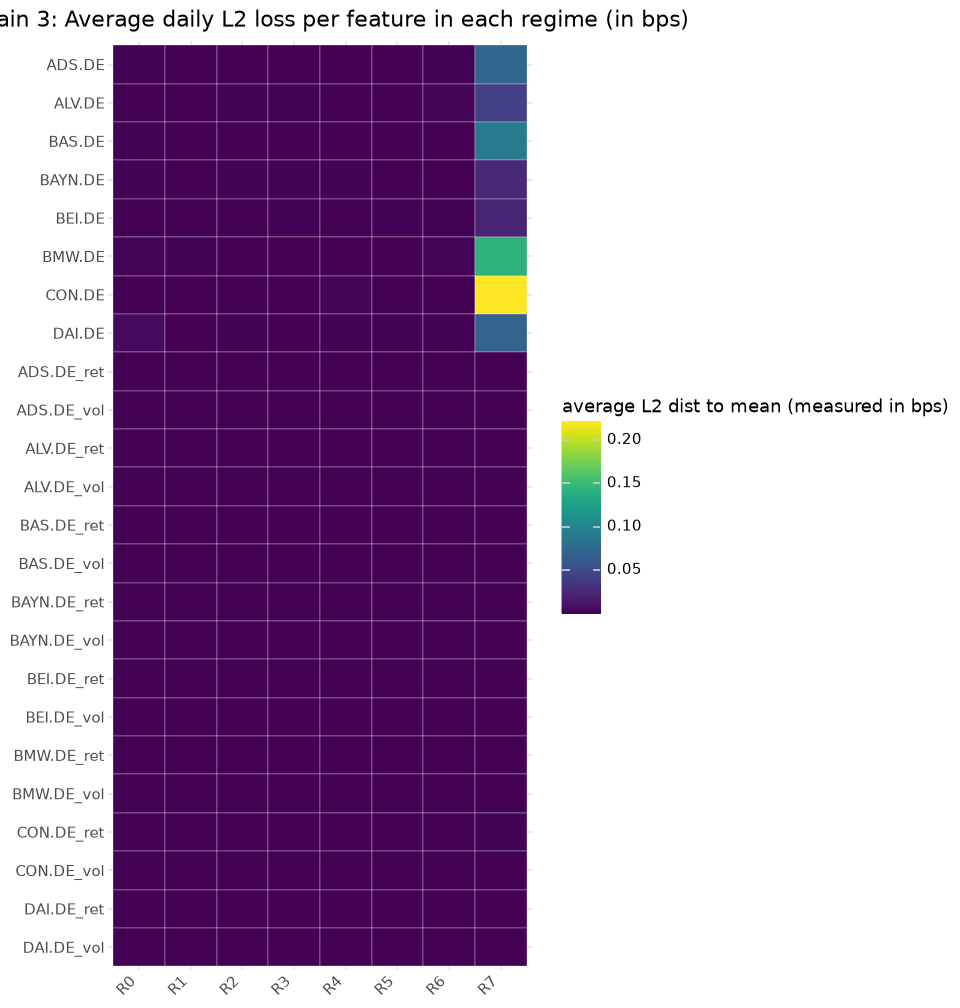

  bkpt_tests_20260805_112904\0\retrain_iteration_0_avg_feature_L2.png


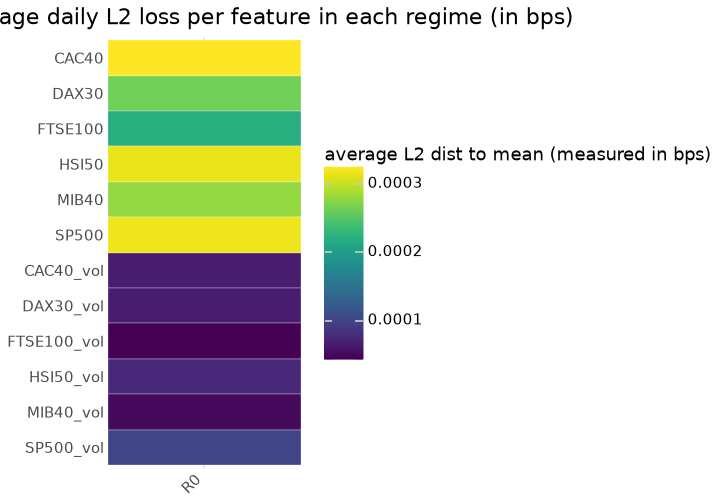

In [44]:
g2_dmd_dir = run_g2(
    features_df, params_dmd, proc_dmd, OUT_DIR / "dmd" / "graph2", "DMD", plot_cols, max_iter=3
)


---
# Part D — Search methods (Binseg / BottomUp / WBS / BOCPD)

Same PCA + MMD as Part A; only `algo.search_method` changes (incl. **WBS** / **BOCPD**).


## D.1 Binseg


In [45]:
params_binseg = with_search(equity_params(OUT_DIR / "binseg"), SearchMethod.BINSEG)
params_binseg = with_dimred(params_binseg, "pca")
proc_binseg = run_g1(features_df, params_binseg, "Binseg", plot_cols)


=== Graph 1 · Binseg · backend=['kernel_ruptures'] dimred=['pca'] detector=[] search=['binseg'] test=['mmd_no_ts'] ===
[Binseg] kept=[45]  invalid=[]
  bkpt 45 → 2007-04-12 00:00:00
<ggplot: (1400 x 560)>


## D.2 BottomUp


In [46]:
params_bottomup = with_search(equity_params(OUT_DIR / "bottomup"), SearchMethod.BOTTOMUP)
params_bottomup = with_dimred(params_bottomup, "pca")
proc_bottomup = run_g1(features_df, params_bottomup, "BottomUp", plot_cols)


=== Graph 1 · BottomUp · backend=['kernel_ruptures'] dimred=['pca'] detector=[] search=['bottomup'] test=['mmd_no_ts'] ===
[BottomUp] kept=[20, 80]  invalid=[]
  bkpt 20 → 2007-03-05 00:00:00
  bkpt 80 → 2007-06-06 00:00:00
<ggplot: (1400 x 560)>


## D.3 Wild Binary Segmentation (WBS)


In [47]:
params_wbs = with_search(
    equity_params(OUT_DIR / "wbs"),
    SearchMethod.WBS,
    wbs_n_intervals=200,
    random_state=42,
)
params_wbs = with_dimred(params_wbs, "pca")
proc_wbs = run_g1(features_df, params_wbs, "WBS", plot_cols)


=== Graph 1 · WBS · backend=['kernel_ruptures'] dimred=['pca'] detector=[] search=['wbs'] test=['mmd_no_ts'] ===
[WBS] kept=[113, 381, 542]  invalid=[]
  bkpt 113 → 2007-07-26 00:00:00
  bkpt 381 → 2008-09-16 00:00:00
  bkpt 542 → 2009-05-22 00:00:00
<ggplot: (1400 x 560)>


## D.4 Bayesian Online Changepoint Detection (BOCPD)


In [48]:
params_bocpd = with_search(
    equity_params(OUT_DIR / "bocpd"),
    SearchMethod.BOCPD,
    bocpd_hazard=0.01,
    bocpd_threshold=0.4,
    bocpd_max_run=200,
)
params_bocpd = with_dimred(params_bocpd, "pca")
proc_bocpd = run_g1(features_df, params_bocpd, "BOCPD", plot_cols)


=== Graph 1 · BOCPD · backend=['kernel_ruptures'] dimred=['pca'] detector=[] search=['bocpd'] test=['mmd_no_ts'] ===
[BOCPD] kept=[1067]  invalid=[]
  bkpt 1067 → 2011-08-04 00:00:00
<ggplot: (1400 x 560)>


---
# Part E — Statistical tests

Swap `test.choice`: energy distance, unbiased / linear-time MMD, Hotelling T²,
multivariate CUSUM, KS on PCA scores.


## E.1 Energy distance


In [49]:
params_energy = with_test(
    with_dimred(equity_params(OUT_DIR / "energy"), "pca"),
    StatTest.ENERGY_DISTANCE,
)
proc_energy = run_g1(features_df, params_energy, "energy_distance", plot_cols)


=== Graph 1 · energy_distance · backend=['kernel_ruptures'] dimred=['pca'] detector=[] search=['pelt'] test=['energy_distance'] ===
[energy_distance] kept=[]  invalid=[]
<ggplot: (1400 x 560)>


## E.2 Unbiased MMD


In [50]:
params_mmd_u = with_test(
    with_dimred(equity_params(OUT_DIR / "mmd_unbiased"), "pca"),
    StatTest.MMD_UNBIASED,
)
proc_mmd_u = run_g1(features_df, params_mmd_u, "mmd_unbiased", plot_cols)


=== Graph 1 · mmd_unbiased · backend=['kernel_ruptures'] dimred=['pca'] detector=[] search=['pelt'] test=['mmd_unbiased'] ===
[mmd_unbiased] kept=[]  invalid=[]
<ggplot: (1400 x 560)>


## E.3 Linear-time MMD


In [51]:
params_mmd_linear = with_test(equity_params(OUT_DIR / "mmd_linear"), StatTest.MMD_LINEAR)
params_mmd_linear = with_dimred(params_mmd_linear, "pca")
proc_mmd_lin = run_g1(features_df, params_mmd_linear, "mmd_linear", plot_cols)


=== Graph 1 · mmd_linear · backend=['kernel_ruptures'] dimred=['pca'] detector=[] search=['pelt'] test=['mmd_linear'] ===
[mmd_linear] kept=[]  invalid=[]
<ggplot: (1400 x 560)>


## E.4 Hotelling T²


In [52]:
params_hotelling_t2 = with_test(equity_params(OUT_DIR / "hotelling_t2"), StatTest.HOTELLING_T2)
params_hotelling_t2 = with_dimred(params_hotelling_t2, "pca")
proc_hotelling = run_g1(features_df, params_hotelling_t2, "hotelling_t2", plot_cols)


=== Graph 1 · hotelling_t2 · backend=['kernel_ruptures'] dimred=['pca'] detector=[] search=['pelt'] test=['hotelling_t2'] ===
[hotelling_t2] kept=[]  invalid=[]
<ggplot: (1400 x 560)>


## E.5 Multivariate CUSUM


In [53]:
params_multivariate_cusum = with_test(equity_params(OUT_DIR / "multivariate_cusum"), StatTest.MULTIVARIATE_CUSUM)
params_multivariate_cusum = with_dimred(params_multivariate_cusum, "pca")
proc_mcusum = run_g1(features_df, params_multivariate_cusum, "multivariate_cusum", plot_cols)


=== Graph 1 · multivariate_cusum · backend=['kernel_ruptures'] dimred=['pca'] detector=[] search=['pelt'] test=['multivariate_cusum'] ===
[multivariate_cusum] kept=[]  invalid=[]
<ggplot: (1400 x 560)>


## E.6 KS on PCA scores


In [54]:
params_ks_pca = with_test(equity_params(OUT_DIR / "ks_pca"), StatTest.KS_PCA)
params_ks_pca = with_dimred(params_ks_pca, "pca")
proc_ks_pca = run_g1(features_df, params_ks_pca, "ks_pca", plot_cols)


=== Graph 1 · ks_pca · backend=['kernel_ruptures'] dimred=['pca'] detector=[] search=['pelt'] test=['ks_pca'] ===
[ks_pca] kept=[]  invalid=[]
<ggplot: (1400 x 560)>


---
# Part F — ESS window


In [55]:
params_ess = with_ess_window(
    with_dimred(equity_params(OUT_DIR / "ess"), "pca"),
    ess_fraction=0.25,
    min_window=20,
    max_window=100,
)
# equity_params sets a fixed window; with_ess_window overwrites it
proc_ess = run_g1(features_df, params_ess, "ESS window", plot_cols)


=== Graph 1 · ESS window · backend=['kernel_ruptures'] dimred=['pca'] detector=[] search=['pelt'] test=['mmd_no_ts'] ===
[ESS window] kept=[]  invalid=[]
<ggplot: (1400 x 560)>


---
# Part G — Classical hard-label detectors

`detection_backend: classical` (former legacy CLI). Hard labels → breakpoints;
Graph 2 can still seed from the result.


## G.1 k-means (classical)


In [56]:
params_ckmeans = with_classical(
    equity_params(OUT_DIR / "classical_kmeans"),
    ClassicalDetector.KMEANS,
    regimes=3,
    random_state=42,
)
proc_ckmeans = run_g1(features_df, params_ckmeans, "classical kmeans", plot_cols)


=== Graph 1 · classical kmeans · backend=['classical'] dimred=['raw'] detector=['kmeans'] search=['pelt'] test=['mmd_no_ts'] ===
[classical kmeans] kept=[]  invalid=[]
<ggplot: (1400 x 560)>


## G.2 HMM (classical)


In [57]:
params_chmm = with_classical(
    equity_params(OUT_DIR / "classical_hmm"),
    ClassicalDetector.HMM,
    regimes=3,
    hmm_emissions="gaussian",
    hmm_n_iter=50,
)
proc_chmm = run_g1(features_df, params_chmm, "classical HMM", plot_cols)


=== Graph 1 · classical HMM · backend=['classical'] dimred=['raw'] detector=['hmm'] search=['pelt'] test=['mmd_no_ts'] ===


WARNING [hmmlearn.base] Model is not converging.  Current: 65660.63939754284 is not greater than 65660.84912470313. Delta is -0.20972716029791627


[classical HMM] kept=[150, 181, 282, 329, 562, 589, 1004, 1024, 1067, 1147]  invalid=[]
  bkpt 150 → 2007-09-20 00:00:00
  bkpt 181 → 2007-11-07 00:00:00
  bkpt 282 → 2008-04-15 00:00:00
  bkpt 329 → 2008-06-26 00:00:00
  bkpt 562 → 2009-06-23 00:00:00
  bkpt 589 → 2009-08-03 00:00:00
  bkpt 1004 → 2011-04-29 00:00:00
  bkpt 1024 → 2011-06-01 00:00:00
  bkpt 1067 → 2011-08-04 00:00:00
  bkpt 1147 → 2011-12-06 00:00:00
<ggplot: (1400 x 560)>


## G.3 Jump model (classical)


In [58]:
params_cjump = with_classical(
    equity_params(OUT_DIR / "classical_jump_model"),
    ClassicalDetector.JUMP_MODEL,
    regimes=3,
    jump_penalty=5.0,
    jump_max_iter=20,
)
proc_cjump = run_g1(features_df, params_cjump, "classical jump_model", plot_cols)


=== Graph 1 · classical jump_model · backend=['classical'] dimred=['raw'] detector=['jump_model'] search=['pelt'] test=['mmd_no_ts'] ===


StopIteration: 

## G.4 Sticky HDP-HMM (classical)


In [ ]:
params_chdp = with_classical(
    equity_params(OUT_DIR / "classical_sticky_hdp_hmm"),
    ClassicalDetector.STICKY_HDP_HMM,
    regimes=3,
)
proc_chdp = run_g1(features_df, params_chdp, "classical sticky_hdp_hmm", plot_cols)


## G.5 GARCH volatility regimes (classical)


In [59]:
params_cgarch = with_classical(
    equity_params(OUT_DIR / "classical_garch"),
    ClassicalDetector.GARCH,
    regimes=2,
    garch_p=1,
    garch_q=1,
)
proc_cgarch = run_g1(features_df, params_cgarch, "classical garch", plot_cols)


=== Graph 1 · classical garch · backend=['classical'] dimred=['raw'] detector=['garch'] search=['pelt'] test=['mmd_no_ts'] ===


StopIteration: 

## G.6 Graph 2 seeded from classical k-means


INFO [gulfstream.common.logging] Logging to d:\Code\gulfstream\outputs\logs\gulfstream_20260805_112936.log
INFO [gulfstream.pipelines.graph2.reporting] Generating L2 error matrix.


=== Graph 2 · classical kmeans · score_method=mse_to_mean · seeding from Graph 1 ===
[{'Start': datetime.datetime(2007, 2, 1, 0, 0), 'End': datetime.datetime(2012, 12, 28, 0, 0), 'Regime': 0, 'Hierarchy Level of End': 0}]
Current breakpoint hierarchy: 
{}


INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\classical_kmeans\graph2\bkpt_tests_20260805_112936\0\retrain_iteration_0_avg_feature_L2.png
INFO [gulfstream.pipelines.graph2.reporting] Saved error matrix to d:\Code\gulfstream\outputs\notebooks\equity\classical_kmeans\graph2\bkpt_tests_20260805_112936\0/retrain_iteration_0_avg_feature_L2.png.
INFO [gulfstream.metrics.writers] Regime stats: processed bkpts=[] invalid=[] (raw bkpts=[])
INFO [gulfstream.pipelines.graph2.reporting] Producing all explainability and visualization tools.


Retraining in regime 0 with features DAX30, MIB40, HSI50, SP500, CAC40.
Done retraining in regime 0.
Failed to find a breakpoint in the highest error regime. Quitting.


INFO [gulfstream.common.plotting] Saved regime plot to d:\Code\gulfstream\outputs\notebooks\equity\classical_kmeans\graph2\bkpt_tests_20260805_112936\0\02_regime_plot.png
INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\classical_kmeans\graph2\bkpt_tests_20260805_112936\0\04_avg_L2.png


<ggplot: (1400 x 839)>
<ggplot: (400 x 325)>


INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\classical_kmeans\graph2\bkpt_tests_20260805_112936\0\05_aggregated_L2.png
INFO [gulfstream.metrics.insights] Fewer than 2 regimes; skipping distance/cluster insights.
INFO [gulfstream.detection.trees] Saved breakpoint tree to d:\Code\gulfstream\outputs\notebooks\equity\classical_kmeans\graph2\bkpt_tests_20260805_112936\0\01_proc_bkpt_tree.png
d:\Code\gulfstream\src\gulfstream\detection\trees.py:113: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
WARNING [gulfstream.metrics.explainability] Fewer than 2 regimes; skipping explainability trees.
INFO [gulfstream.pipelines.graph2.loop] Targeted retrain done. Outputs in ..\outputs\notebooks\equity\classical_kmeans\graph2\bkpt_tests_20260805_112936


<ggplot: (400 x 300)>
[classical kmeans Graph 2] kept=[]  invalid=[]
<ggplot: (1400 x 560)>
Graph 2 artifacts under d:\Code\gulfstream\outputs\notebooks\equity\classical_kmeans\graph2
  bkpt_tests_20260805_112936\0\retrain_iteration_0_avg_feature_L2.png


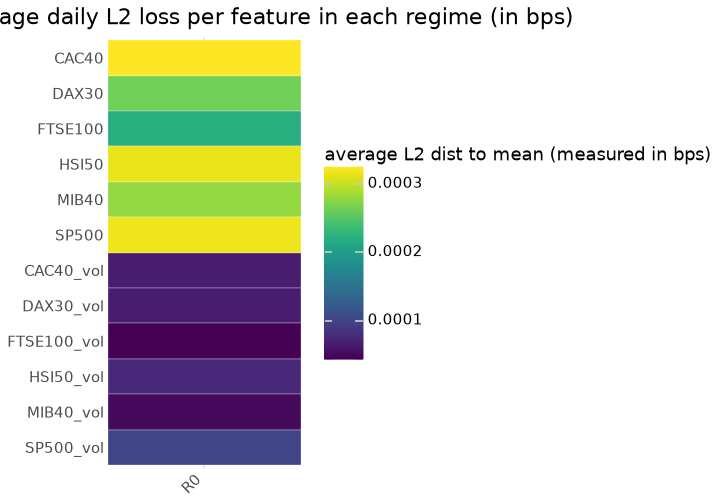

In [60]:
g2_ckmeans_dir = run_g2(
    features_df,
    params_ckmeans,
    proc_ckmeans,
    OUT_DIR / "classical_kmeans" / "graph2",
    "classical kmeans",
    plot_cols,
    max_iter=2,
)


---
# Part H — Classical models as soft dimred

`algo.dimred: [kmeans|hmm]` with `detection_backend: kernel_ruptures`.


## H.1 k-means dimred


In [61]:
params_kmeans_dim = with_model_dimred(
    equity_params(OUT_DIR / "kmeans_dimred"),
    "kmeans",
    regimes=3,
)
proc_kmeans_dim = run_g1(features_df, params_kmeans_dim, "kmeans dimred", plot_cols)


ERROR [hamilton.execution.graph_functions] 
********************************************************************************
> dimred_result [gulfstream.pipelines.hamilton.segmentation.dimred_result()] encountered an error<
> Node inputs:
{'features_df': 'shape: (1_392, 13)\n┌───────────┬───────────┬──────...',
 'prepared_params': "{'algo': {'dimred': ['kmeans'], 'rank_selection_me..."}
********************************************************************************
Traceback (most recent call last):
  File "d:\Code\gulfstream\.venv\Lib\site-packages\hamilton\execution\graph_functions.py", line 321, in execute_lifecycle_for_node
    result = __node_(**__kwargs)
  File "d:\Code\gulfstream\.venv\Lib\site-packages\hamilton\node.py", line 282, in __call__
    return self.callable(*args, **kwargs)
           ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "d:\Code\gulfstream\src\gulfstream\pipelines\hamilton\segmentation.py", line 55, in dimred_result
    return next(dimension_reduction.dimred_genera

=== Graph 1 · kmeans dimred · backend=['kernel_ruptures'] dimred=['kmeans'] detector=[] search=['pelt'] test=['mmd_no_ts'] ===


StopIteration: 

## H.2 HMM dimred


In [62]:
params_hmm_dim = with_model_dimred(
    equity_params(OUT_DIR / "hmm_dimred"),
    "hmm",
    regimes=3,
)
proc_hmm_dim = run_g1(features_df, params_hmm_dim, "HMM dimred", plot_cols)


=== Graph 1 · HMM dimred · backend=['kernel_ruptures'] dimred=['hmm'] detector=[] search=['pelt'] test=['mmd_no_ts'] ===
[HMM dimred] kept=[110, 130]  invalid=[]
  bkpt 110 → 2007-07-23 00:00:00
  bkpt 130 → 2007-08-21 00:00:00
<ggplot: (1400 x 560)>


---
# Part I — TFT dimred (Temporal Fusion Transformer)

TFT attention embeddings as Graph 1 dimred. Smoke settings (1 epoch). Uses
**multivariate** mode so the multi-stock return panel stays tractable.


## I.1 Graph 1 (TFT)


In [63]:
try:
    import torch  # noqa: F401
    import lightning  # noqa: F401
    import pytorch_forecasting  # noqa: F401
    _TFT_OK = True
except ImportError as exc:
    _TFT_OK = False
    print("TFT stack unavailable — skipping Part I:", exc)

if _TFT_OK:
    params_tft = with_tft(equity_params(OUT_DIR / "tft"))
    print(
        "TFT smoke:",
        f"n={features_df.height}",
        f"enc={params_tft['algo']['tft_encoder_length']}",
        f"epochs={params_tft['algo']['tft_max_epochs']}",
    )
    proc_tft = run_g1(features_df, params_tft, "TFT dimred", plot_cols)
else:
    proc_tft = proc_pca


d:\Code\gulfstream\.venv\Lib\site-packages\pytorch_forecasting\models\base\_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


TFT smoke: n=1392 enc=[20] epochs=[1]
=== Graph 1 · TFT dimred · backend=['kernel_ruptures'] dimred=['tft'] detector=[] search=['pelt'] test=['mmd_no_ts'] ===


d:\Code\gulfstream\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
d:\Code\gulfstream\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: False, used: False
INFO [lightning.pytorch.utilities.rank_zero] GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO [lightning.pytorch.utilities.rank_zero] TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

d:\Code\gulfstream\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\Code\gulfstream\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.


d:\Code\gulfstream\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\Code\gulfstream\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 68/68 [00:04<00:00, 14.08it/s, train_loss_step=0.00758, val_loss=0.00657, train_loss_epoch=0.00902]

INFO: `Trainer.fit` stopped: `max_epochs=1` reached.
INFO [lightning.pytorch.utilities.rank_zero] `Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 0: 100%|██████████| 68/68 [00:04<00:00, 14.08it/s, train_loss_step=0.00758, val_loss=0.00657, train_loss_epoch=0.00902]
[TFT dimred] kept=[20]  invalid=[]
  bkpt 20 → 2007-03-05 00:00:00
<ggplot: (1400 x 560)>


## I.2 Graph 2 seeded from TFT


INFO [gulfstream.common.logging] Logging to d:\Code\gulfstream\outputs\logs\gulfstream_20260805_113000.log
INFO [gulfstream.pipelines.graph2.reporting] Generating L2 error matrix.


=== Graph 2 · TFT · score_method=mse_to_mean · seeding from Graph 1 ===
[{'Start': datetime.datetime(2007, 2, 1, 0, 0), 'End': datetime.datetime(2007, 3, 5, 0, 0), 'Regime': 0, 'Hierarchy Level of End': 1}, {'Start': datetime.datetime(2007, 3, 5, 0, 0), 'End': datetime.datetime(2012, 12, 28, 0, 0), 'Regime': 1, 'Hierarchy Level of End': 0}]
Current breakpoint hierarchy: 
{
    "2007-03-05": 1
}


INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\tft\graph2\bkpt_tests_20260805_113000\0\retrain_iteration_0_avg_feature_L2.png
INFO [gulfstream.pipelines.graph2.reporting] Saved error matrix to d:\Code\gulfstream\outputs\notebooks\equity\tft\graph2\bkpt_tests_20260805_113000\0/retrain_iteration_0_avg_feature_L2.png.
d:\Code\gulfstream\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
d:\Code\gulfstream\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO [gulfstream.detectors.tft] Number of parameters in network: 8.1k.
INFO: GPU availabl

Retraining in regime 1 with features DAX30, MIB40, HSI50, SP500, CAC40.
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

d:\Code\gulfstream\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\Code\gulfstream\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.


...

<ggplot: (600 x 500)>


INFO [gulfstream.metrics.explainability] Saved explainability tree to d:\Code\gulfstream\outputs\notebooks\equity\tft\graph2\bkpt_tests_20260805_113000\0\03_shallow_exp_tree.png
INFO [gulfstream.metrics.explainability] Pickled tree to d:\Code\gulfstream\outputs\notebooks\equity\tft\graph2\bkpt_tests_20260805_113000\0\shallow_exp_tree.pkl
INFO [gulfstream.metrics.explainability] Accurate tree depth=1 train_acc=0.971 target=0.900
INFO [gulfstream.metrics.explainability] Saved explainability tree to d:\Code\gulfstream\outputs\notebooks\equity\tft\graph2\bkpt_tests_20260805_113000\0\03_acc90_exp_tree.png
INFO [gulfstream.metrics.explainability] Pickled tree to d:\Code\gulfstream\outputs\notebooks\equity\tft\graph2\bkpt_tests_20260805_113000\0\acc90_exp_tree_pickle.pkl
INFO [gulfstream.common.plotting] Saved transition matrix to d:\Code\gulfstream\outputs\notebooks\equity\tft\graph2\bkpt_tests_20260805_113000\0\32_transition_distance.png


<ggplot: (400 x 300)>


INFO [gulfstream.common.plotting] Saved transition matrix to d:\Code\gulfstream\outputs\notebooks\equity\tft\graph2\bkpt_tests_20260805_113000\0\33_transition_tree.png
INFO [gulfstream.pipelines.graph2.loop] Targeted retrain done. Outputs in ..\outputs\notebooks\equity\tft\graph2\bkpt_tests_20260805_113000


<ggplot: (400 x 300)>
[TFT Graph 2] kept=[20, 40]  invalid=[]
  bkpt 20 → 2007-03-05 00:00:00
  bkpt 40 → 2007-04-02 00:00:00
<ggplot: (1400 x 560)>
Graph 2 artifacts under d:\Code\gulfstream\outputs\notebooks\equity\tft\graph2
  bkpt_tests_20260805_113000\0\retrain_iteration_0_avg_feature_L2.png


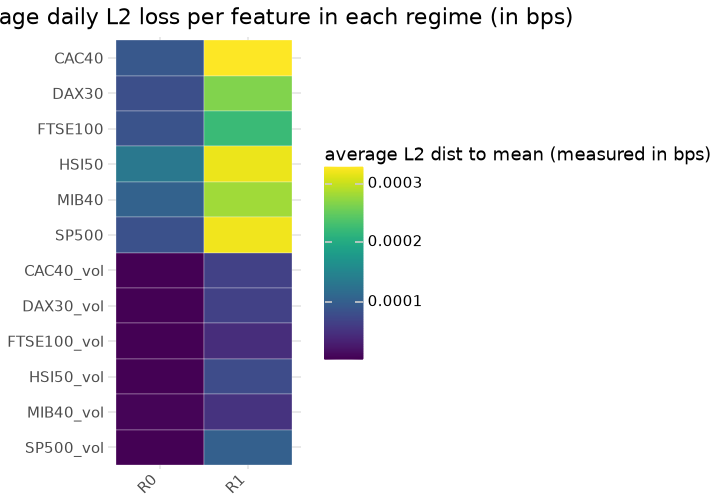

  bkpt_tests_20260805_113000\0\retrain_iteration_1_avg_feature_L2.png


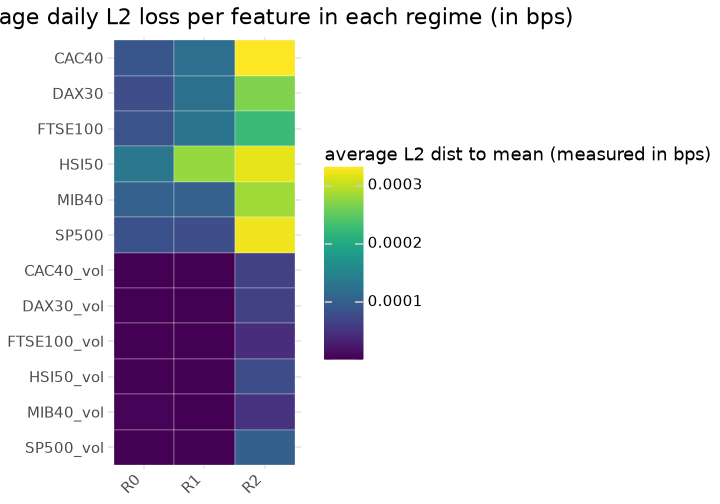

In [64]:
if _TFT_OK:
    g2_tft_dir = run_g2(
        features_df,
        params_tft,
        proc_tft,
        OUT_DIR / "tft" / "graph2",
        "TFT",
        plot_cols,
        max_iter=1,
    )
else:
    print("Skipping TFT Graph 2")


---
# Part J — Curve / ICA dimred

**ICA**, **FPCA**, **Nelson–Siegel**, and **dynamic_factor** embeddings into the
default kernel_ruptures stack. Nelson–Siegel treats feature columns as an ordered
grid (1..p when names are not tenors).


## J.1 ICA


In [65]:
params_ica = with_dimred(equity_params(OUT_DIR / "ica"), "ica")
proc_ica = run_g1(features_df, params_ica, "ICA dimred", plot_cols)


=== Graph 1 · ICA dimred · backend=['kernel_ruptures'] dimred=['ica'] detector=[] search=['pelt'] test=['mmd_no_ts'] ===
[ICA dimred] kept=[]  invalid=[]
<ggplot: (1400 x 560)>


## J.2 Functional PCA


In [66]:
params_fpca = with_dimred(equity_params(OUT_DIR / "fpca"), "fpca")
proc_fpca = run_g1(features_df, params_fpca, "FPCA dimred", plot_cols)


=== Graph 1 · FPCA dimred · backend=['kernel_ruptures'] dimred=['fpca'] detector=[] search=['pelt'] test=['mmd_no_ts'] ===
[FPCA dimred] kept=[]  invalid=[]
<ggplot: (1400 x 560)>


## J.3 Nelson–Siegel


In [67]:
params_ns = with_dimred(equity_params(OUT_DIR / "nelson_siegel"), "nelson_siegel")
proc_ns = run_g1(features_df, params_ns, "Nelson–Siegel dimred", plot_cols)


=== Graph 1 · Nelson–Siegel dimred · backend=['kernel_ruptures'] dimred=['nelson_siegel'] detector=[] search=['pelt'] test=['mmd_no_ts'] ===
[Nelson–Siegel dimred] kept=[]  invalid=[15]
<ggplot: (1400 x 560)>


## J.4 Dynamic factor


In [68]:
params_dfactor = with_dimred(equity_params(OUT_DIR / "dynamic_factor"), "dynamic_factor")
proc_dfactor = run_g1(features_df, params_dfactor, "dynamic_factor dimred", plot_cols)


=== Graph 1 · dynamic_factor dimred · backend=['kernel_ruptures'] dimred=['dynamic_factor'] detector=[] search=['pelt'] test=['mmd_no_ts'] ===


d:\Code\gulfstream\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals


[dynamic_factor dimred] kept=[]  invalid=[]
<ggplot: (1400 x 560)>


---
# Part K — Product features (uncertainty, export, events, streaming, panel)

Dashboard / ops knobs on the same equity feature matrix:

1. **Uncertainty** → `bkpt_ci` shaded as **CI ribbons** (`metrics.plot_ci_ribbons`)
2. **Excel** + **NDJSON events** (`export.excel` / `events`, optional path or dir+filename)
3. **Streaming** expanding Graph 1
4. **Panel joint** consensus (column groups when tickers lack `SOURCE_TENOR` names)


## K.1 Uncertainty bands + CI ribbon overlays


In [69]:
from gulfstream.metrics import uncertainty as uncertainty_mod

product_dir = OUT_DIR / "product"
product_dir.mkdir(parents=True, exist_ok=True)

params_unc = with_dimred(equity_params(product_dir / "uncertainty"), "pca")
params_unc["metrics"]["plot_ci_ribbons"] = True
params_unc["uncertainty"] = {
    "enabled": True,
    "sources": ["bootstrap"],
    "level": 0.9,
    "match_tolerance": 5,
    "n_bootstrap": 4,
    "bootstrap_block": 25,
    "random_state": 42,
}

proc_unc = run_g1(features_df, params_unc, "PCA + uncertainty", plot_cols)
proc_unc = uncertainty_mod.evaluate_uncertainty(
    features_df,
    {**params_unc, "_pipeline_params": params_unc},
    proc_unc,
)
print("bkpt_ci:", proc_unc.bkpt_ci)
fig_graph_1_pca_ci_ribbons = plot_regimes(
    features_df,
    proc_unc,
    variables=plot_cols[:2],
    title="Graph 1 · PCA + CI ribbons",
    mode="display",
    emit=False,
)
fig_graph_1_pca_ci_ribbons


=== Graph 1 · PCA + uncertainty · backend=['kernel_ruptures'] dimred=['pca'] detector=[] search=['pelt'] test=['mmd_no_ts'] ===
[PCA + uncertainty] kept=[]  invalid=[]
<ggplot: (1400 x 560)>
bkpt_ci: {}
<ggplot: (1400 x 560)>


## K.2 Excel export + NDJSON event stream

Optional `export.excel.path` **or** `dir` + `filename`. Example YAML: `config/graph1/graph1_export_events.yaml`.


In [70]:
import json

from gulfstream.metrics.writers import export_breakpoint_excel
from gulfstream.ops.events import emit_run_events
import pandas as pd

export_dir = product_dir / "export_events"
export_dir.mkdir(parents=True, exist_ok=True)

params_export = copy.deepcopy(params_unc)
params_export["metrics"]["dir"] = str(export_dir)
params_export["metrics"]["image_dir"] = str(export_dir)
params_export["export"] = {
    "excel": {
        "enabled": True,
        "dir": str(export_dir),
        "filename": "bkpt_export.xlsx",
    }
}
params_export["events"] = {
    "enabled": True,
    "dir": str(export_dir),
    "filename": "events.ndjson",
    "append": False,
}

xlsx_path = export_breakpoint_excel(
    proc_unc,
    params_export,
    dates=frames.dates_series(features_df).to_list(),
)
ndjson_path = emit_run_events(params_export, proc_unc)
print("Excel:", xlsx_path)
print("Events:", ndjson_path)

if ndjson_path:
    for line in Path(ndjson_path).read_text(encoding="utf-8").strip().splitlines():
        evt = json.loads(line)
        print(f"  {evt['event']}")

if xlsx_path:
    display(pd.read_excel(xlsx_path, sheet_name="Breakpoints"))
    display(pd.read_excel(xlsx_path, sheet_name="CI"))


Excel: d:\Code\gulfstream\outputs\notebooks\equity\product\export_events\bkpt_export.xlsx
Events: d:\Code\gulfstream\outputs\notebooks\equity\product\export_events\events.ndjson
  run_started
  run_complete


""


""


## K.3 Streaming Graph 1 (expanding)


In [71]:
from gulfstream import detect_regimes_incremental

stream_dir = product_dir / "streaming"
stream_dir.mkdir(parents=True, exist_ok=True)

params_stream = with_dimred(equity_params(stream_dir), "pca")
params_stream["metrics"]["plot"] = False
params_stream["streaming"] = {
    "enabled": True,
    "mode": "expanding",
    "step": 60,
    "min_history": 150,
    "lock_prefix": True,
    "match_tolerance": 5,
}

state = None
proc_stream = None
for step_i in range(3):
    proc_stream, state = detect_regimes_incremental(features_df, params_stream, state)
    print(f"step={step_i} last_t={state.last_t} bkpts={proc_stream.bkpts}")

summarize(proc_stream, "streaming (last step)", features_df)
fig_streaming_graph_1_last_step = plot_regimes(
    features_df,
    proc_stream,
    variables=plot_cols[:2],
    title="Streaming Graph 1 (last step)",
    mode="display",
    emit=False,
)
fig_streaming_graph_1_last_step


step=0 last_t=150 bkpts=[]
step=1 last_t=210 bkpts=[]
step=2 last_t=270 bkpts=[]
[streaming (last step)] kept=[]  invalid=[]
<ggplot: (1400 x 560)>


## K.4 Panel joint breakpoints

Without `SOURCE_TENOR` column names, the panel path splits features into two column groups and takes a majority consensus.


In [72]:
from gulfstream import detect_regimes_panel

panel_dir = product_dir / "panel"
panel_dir.mkdir(parents=True, exist_ok=True)

params_panel = with_dimred(equity_params(panel_dir), "pca")
params_panel["metrics"]["plot"] = False
params_panel["panel"] = {
    "enabled": True,
    "groupby": "columns",  # fallback split when no source/tenor prefixes
    "combine": "majority",
    "min_group_frac": 0.5,
    "match_tolerance": 5,
}

proc_panel = detect_regimes_panel(features_df, params_panel)
summarize(proc_panel, "panel majority", features_df)
print("panel_support:", proc_panel.panel_support)
fig_panel_joint_column_majority = plot_regimes(
    features_df,
    proc_panel,
    variables=plot_cols[:2],
    title="Panel joint (column majority)",
    mode="display",
    emit=False,
)
fig_panel_joint_column_majority


[panel majority] kept=[]  invalid=[]
panel_support: {}
<ggplot: (1400 x 560)>


---
# Part L — Graph 2 retrain score methods

Graph 2 picks the next slice from a **feature × regime** score matrix
(`retrain.score_method`). Default `mse_to_mean` is the legacy L2 heatmap.
**`threshold` is in the chosen score’s units** — retune when switching methods.

| Method | Idea |
|--------|------|
| `mse_to_mean` | L2 to regime mean (default) |
| `mad_to_median` | Robust L1 twin |
| `mse_on_diff` | MSE on first differences (good for log-prices) |
| `factor_residual` | Within-regime PCA residual |
| `hotelling_within` / `cusum_intensity` | Detection-aligned leftovers |
| `energy_split` / `mmd_split` | Best mid-window two-sample split |


## L.1 Compare score matrices on the PCA Graph 1 seed

No Graph 2 run yet — each scorer reports which (feature, regime) it would refine first.


In [73]:
import numpy as np

from gulfstream.metrics.regime_scores import known_score_methods, score_feature_regime

score_dir = OUT_DIR / "graph2_scores"
score_dir.mkdir(parents=True, exist_ok=True)

feat_for_scores = [c for c in plot_cols if c in frames.feature_columns(features_df)]
score_df = frames.select_features(features_df, feat_for_scores)
bkpts_seed = list(proc_pca.bkpts)
feat_names = frames.feature_columns(score_df)

split_kwargs = {"n_splits": 5, "min_side": 10, "max_rows": 80}
specs = [
    ("mse_to_mean", {}),
    ("mad_to_median", {}),
    ("mse_on_diff", {"diff_order": 1}),
    ("factor_residual", {"n_components": 1}),
    ("hotelling_within", {}),
    ("cusum_intensity", {}),
    ("energy_split", split_kwargs),
    ("mmd_split", {**split_kwargs, "mmd_estimator": "linear"}),
]

rows = []
for method, kwargs in specs:
    mat = score_feature_regime(score_df, bkpts_seed, method, **kwargs)
    fi, ri = np.unravel_index(int(np.argmax(mat)), mat.shape)
    rows.append(
        {
            "score_method": method,
            "worst_feature": feat_names[fi],
            "worst_regime": int(ri),
            "max_score": float(mat[fi, ri]),
            "n_feat": mat.shape[0],
            "n_regimes": mat.shape[1],
        }
    )
    print(f"{method:18s} → {feat_names[fi]} @ regime {ri}  (max={mat[fi, ri]:.4g})")

print("Available methods:", known_score_methods())
score_pick_table = pl.DataFrame(rows)
score_pick_table


mse_to_mean        → CAC40 @ regime 0  (max=0.0003262)
mad_to_median      → CAC40 @ regime 0  (max=0.01289)
mse_on_diff        → CAC40 @ regime 0  (max=0.0006333)
factor_residual    → FTSE100 @ regime 0  (max=1.863e-05)
hotelling_within   → FTSE100 @ regime 0  (max=0.001309)
cusum_intensity    → DAX30 @ regime 0  (max=19.57)
energy_split       → DAX30 @ regime 0  (max=0.001911)
mmd_split          → DAX30 @ regime 0  (max=0.17)
Available methods: ['mse_to_mean', 'mad_to_median', 'mse_on_diff', 'factor_residual', 'hotelling_within', 'cusum_intensity', 'energy_split', 'mmd_split']


score_method,worst_feature,worst_regime,max_score,n_feat,n_regimes
str,str,i64,f64,i64,i64
"""mse_to_mean""","""CAC40""",0,0.000326,3,1
"""mad_to_median""","""CAC40""",0,0.012891,3,1
"""mse_on_diff""","""CAC40""",0,0.000633,3,1
"""factor_residual""","""FTSE100""",0,0.000019,3,1
"""hotelling_within""","""FTSE100""",0,0.001309,3,1
"""cusum_intensity""","""DAX30""",0,19.573988,3,1
"""energy_split""","""DAX30""",0,0.001911,3,1
"""mmd_split""","""DAX30""",0,0.169959,3,1


## L.2 Graph 2 with `mse_on_diff` and `factor_residual`

Differenced MSE suits drifting return series; factor residual targets indices that
load on the worst latent factor in each regime.


INFO [gulfstream.common.logging] Logging to d:\Code\gulfstream\outputs\logs\gulfstream_20260805_113021.log
INFO [gulfstream.pipelines.graph2.reporting] Generating MSE-on-diff error matrix.


=== Graph 2 · PCA · mse_on_diff · score_method=mse_on_diff · seeding from Graph 1 ===
[{'Start': datetime.datetime(2007, 2, 1, 0, 0), 'End': datetime.datetime(2012, 12, 28, 0, 0), 'Regime': 0, 'Hierarchy Level of End': 0}]
Current breakpoint hierarchy: 
{}


INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\mse_on_diff\bkpt_tests_20260805_113021\0\retrain_iteration_0_avg_feature_MSE_diff.png
INFO [gulfstream.pipelines.graph2.reporting] Saved error matrix to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\mse_on_diff\bkpt_tests_20260805_113021\0/retrain_iteration_0_avg_feature_MSE_diff.png.


Retraining in regime 0 with features DAX30, MIB40, CAC40, HSI50, SP500.


INFO [gulfstream.metrics.writers] Regime stats: processed bkpts=[] invalid=[] (raw bkpts=[])
INFO [gulfstream.pipelines.graph2.reporting] Producing all explainability and visualization tools.


Done retraining in regime 0.
Failed to find a breakpoint in the highest error regime. Quitting.


INFO [gulfstream.common.plotting] Saved regime plot to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\mse_on_diff\bkpt_tests_20260805_113021\0\02_regime_plot.png
INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\mse_on_diff\bkpt_tests_20260805_113021\0\04_avg_L2.png


<ggplot: (1400 x 839)>
<ggplot: (400 x 325)>


INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\mse_on_diff\bkpt_tests_20260805_113021\0\05_aggregated_L2.png
INFO [gulfstream.metrics.insights] Fewer than 2 regimes; skipping distance/cluster insights.
INFO [gulfstream.detection.trees] Saved breakpoint tree to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\mse_on_diff\bkpt_tests_20260805_113021\0\01_proc_bkpt_tree.png
d:\Code\gulfstream\src\gulfstream\detection\trees.py:113: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
WARNING [gulfstream.metrics.explainability] Fewer than 2 regimes; skipping explainability trees.
INFO [gulfstream.pipelines.graph2.loop] Targeted retrain done. Outputs in ..\outputs\notebooks\equity\graph2_scores\mse_on_diff\bkpt_tests_20260805_113021


<ggplot: (400 x 300)>
[PCA · mse_on_diff Graph 2] kept=[]  invalid=[]
<ggplot: (1400 x 560)>
Graph 2 artifacts under d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\mse_on_diff
  bkpt_tests_20260805_113021\0\retrain_iteration_0_avg_feature_MSE_diff.png


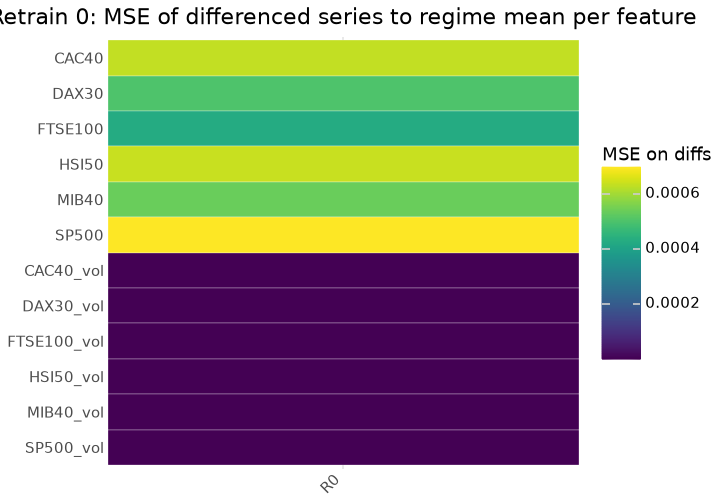

INFO [gulfstream.common.logging] Logging to d:\Code\gulfstream\outputs\logs\gulfstream_20260805_113022.log
INFO [gulfstream.pipelines.graph2.reporting] Generating factor-residual error matrix.


=== Graph 2 · PCA · factor_residual · score_method=factor_residual · seeding from Graph 1 ===
[{'Start': datetime.datetime(2007, 2, 1, 0, 0), 'End': datetime.datetime(2012, 12, 28, 0, 0), 'Regime': 0, 'Hierarchy Level of End': 0}]
Current breakpoint hierarchy: 
{}


INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\factor_residual\bkpt_tests_20260805_113022\0\retrain_iteration_0_avg_feature_factor_resid.png
INFO [gulfstream.pipelines.graph2.reporting] Saved error matrix to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\factor_residual\bkpt_tests_20260805_113022\0/retrain_iteration_0_avg_feature_factor_resid.png.


Retraining in regime 0 with features CAC40_vol, HSI50_vol, SP500_vol, SP500, HSI50.


INFO [gulfstream.metrics.writers] Regime stats: processed bkpts=[] invalid=[] (raw bkpts=[])
INFO [gulfstream.pipelines.graph2.reporting] Producing all explainability and visualization tools.


Done retraining in regime 0.
Failed to find a breakpoint in the highest error regime. Quitting.


INFO [gulfstream.common.plotting] Saved regime plot to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\factor_residual\bkpt_tests_20260805_113022\0\02_regime_plot.png
INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\factor_residual\bkpt_tests_20260805_113022\0\04_avg_L2.png


<ggplot: (1400 x 839)>
<ggplot: (400 x 325)>


INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\factor_residual\bkpt_tests_20260805_113022\0\05_aggregated_L2.png
INFO [gulfstream.metrics.insights] Fewer than 2 regimes; skipping distance/cluster insights.
INFO [gulfstream.detection.trees] Saved breakpoint tree to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\factor_residual\bkpt_tests_20260805_113022\0\01_proc_bkpt_tree.png
d:\Code\gulfstream\src\gulfstream\detection\trees.py:113: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
WARNING [gulfstream.metrics.explainability] Fewer than 2 regimes; skipping explainability trees.
INFO [gulfstream.pipelines.graph2.loop] Targeted retrain done. Outputs in ..\outputs\notebooks\equity\graph2_scores\factor_residual\bkpt_tests_20260805_113022


<ggplot: (400 x 300)>
[PCA · factor_residual Graph 2] kept=[]  invalid=[]
<ggplot: (1400 x 560)>
Graph 2 artifacts under d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\factor_residual
  bkpt_tests_20260805_113022\0\retrain_iteration_0_avg_feature_factor_resid.png


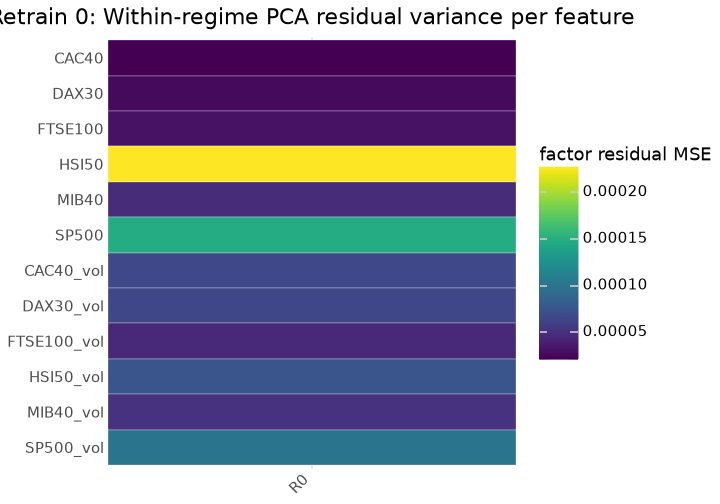

diff heatmaps: [WindowsPath('d:/Code/gulfstream/outputs/notebooks/equity/graph2_scores/mse_on_diff/bkpt_tests_20260805_113021/0/retrain_iteration_0_avg_feature_MSE_diff.png')]
factor heatmaps: [WindowsPath('d:/Code/gulfstream/outputs/notebooks/equity/graph2_scores/factor_residual/bkpt_tests_20260805_113022/0/retrain_iteration_0_avg_feature_factor_resid.png')]


In [74]:
params_g2_scores = with_dimred(equity_params(score_dir), "pca")
params_g2_scores["metrics"]["plot"] = False

g2_diff_dir = run_g2(
    features_df,
    params_g2_scores,
    proc_pca,
    score_dir / "mse_on_diff",
    "PCA · mse_on_diff",
    plot_cols,
    max_iter=2,
    threshold=1e-6,
    score_method="mse_on_diff",
    score={"diff_order": 1},
)

g2_factor_dir = run_g2(
    features_df,
    params_g2_scores,
    proc_pca,
    score_dir / "factor_residual",
    "PCA · factor_residual",
    plot_cols,
    max_iter=2,
    threshold=1e-6,
    score_method="factor_residual",
    score={"n_components": 1},
)
print("diff heatmaps:", list(g2_diff_dir.rglob("retrain_iteration_*.png"))[:3])
print("factor heatmaps:", list(g2_factor_dir.rglob("retrain_iteration_*.png"))[:3])


## L.3 Graph 2 with `energy_split` / `mmd_split`

Kernel-aligned mid-window split scorers (smoke-friendly `n_splits` / `max_rows`).


INFO [gulfstream.common.logging] Logging to d:\Code\gulfstream\outputs\logs\gulfstream_20260805_113024.log
INFO [gulfstream.pipelines.graph2.reporting] Generating energy-split error matrix.


=== Graph 2 · PCA · energy_split · score_method=energy_split · seeding from Graph 1 ===
[{'Start': datetime.datetime(2007, 2, 1, 0, 0), 'End': datetime.datetime(2012, 12, 28, 0, 0), 'Regime': 0, 'Hierarchy Level of End': 0}]
Current breakpoint hierarchy: 
{}


INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\energy_split\bkpt_tests_20260805_113024\0\retrain_iteration_0_avg_feature_energy_split.png
INFO [gulfstream.pipelines.graph2.reporting] Saved error matrix to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\energy_split\bkpt_tests_20260805_113024\0/retrain_iteration_0_avg_feature_energy_split.png.


Retraining in regime 0 with features HSI50, SP500_vol, CAC40_vol, MIB40_vol, HSI50_vol.


INFO [gulfstream.metrics.writers] Regime stats: processed bkpts=[] invalid=[] (raw bkpts=[])
INFO [gulfstream.pipelines.graph2.reporting] Producing all explainability and visualization tools.


Done retraining in regime 0.
Failed to find a breakpoint in the highest error regime. Quitting.


INFO [gulfstream.common.plotting] Saved regime plot to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\energy_split\bkpt_tests_20260805_113024\0\02_regime_plot.png
INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\energy_split\bkpt_tests_20260805_113024\0\04_avg_L2.png


<ggplot: (1400 x 839)>
<ggplot: (400 x 325)>


INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\energy_split\bkpt_tests_20260805_113024\0\05_aggregated_L2.png
INFO [gulfstream.metrics.insights] Fewer than 2 regimes; skipping distance/cluster insights.
INFO [gulfstream.detection.trees] Saved breakpoint tree to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\energy_split\bkpt_tests_20260805_113024\0\01_proc_bkpt_tree.png
d:\Code\gulfstream\src\gulfstream\detection\trees.py:113: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
WARNING [gulfstream.metrics.explainability] Fewer than 2 regimes; skipping explainability trees.
INFO [gulfstream.pipelines.graph2.loop] Targeted retrain done. Outputs in ..\outputs\notebooks\equity\graph2_scores\energy_split\bkpt_tests_20260805_113024


<ggplot: (400 x 300)>
[PCA · energy_split Graph 2] kept=[]  invalid=[]
<ggplot: (1400 x 560)>
Graph 2 artifacts under d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\energy_split
  bkpt_tests_20260805_113024\0\retrain_iteration_0_avg_feature_energy_split.png


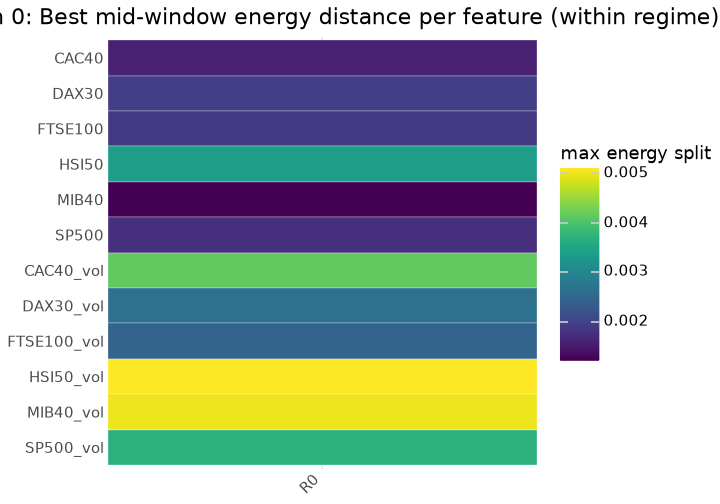

INFO [gulfstream.common.logging] Logging to d:\Code\gulfstream\outputs\logs\gulfstream_20260805_113025.log
INFO [gulfstream.pipelines.graph2.reporting] Generating MMD-split error matrix.


=== Graph 2 · PCA · mmd_split · score_method=mmd_split · seeding from Graph 1 ===
[{'Start': datetime.datetime(2007, 2, 1, 0, 0), 'End': datetime.datetime(2012, 12, 28, 0, 0), 'Regime': 0, 'Hierarchy Level of End': 0}]
Current breakpoint hierarchy: 
{}


INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\mmd_split\bkpt_tests_20260805_113025\0\retrain_iteration_0_avg_feature_mmd_split.png
INFO [gulfstream.pipelines.graph2.reporting] Saved error matrix to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\mmd_split\bkpt_tests_20260805_113025\0/retrain_iteration_0_avg_feature_mmd_split.png.


Retraining in regime 0 with features DAX30_vol, SP500_vol, CAC40_vol, HSI50_vol, MIB40_vol.


INFO [gulfstream.metrics.writers] Regime stats: processed bkpts=[] invalid=[] (raw bkpts=[])
INFO [gulfstream.pipelines.graph2.reporting] Producing all explainability and visualization tools.


Done retraining in regime 0.
Failed to find a breakpoint in the highest error regime. Quitting.


INFO [gulfstream.common.plotting] Saved regime plot to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\mmd_split\bkpt_tests_20260805_113025\0\02_regime_plot.png
INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\mmd_split\bkpt_tests_20260805_113025\0\04_avg_L2.png


<ggplot: (1400 x 839)>
<ggplot: (400 x 325)>


INFO [gulfstream.common.plotting] Saved heatmap to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\mmd_split\bkpt_tests_20260805_113025\0\05_aggregated_L2.png
INFO [gulfstream.metrics.insights] Fewer than 2 regimes; skipping distance/cluster insights.
INFO [gulfstream.detection.trees] Saved breakpoint tree to d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\mmd_split\bkpt_tests_20260805_113025\0\01_proc_bkpt_tree.png
d:\Code\gulfstream\src\gulfstream\detection\trees.py:113: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
WARNING [gulfstream.metrics.explainability] Fewer than 2 regimes; skipping explainability trees.
INFO [gulfstream.pipelines.graph2.loop] Targeted retrain done. Outputs in ..\outputs\notebooks\equity\graph2_scores\mmd_split\bkpt_tests_20260805_113025


<ggplot: (400 x 300)>
[PCA · mmd_split Graph 2] kept=[]  invalid=[]
<ggplot: (1400 x 560)>
Graph 2 artifacts under d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\mmd_split
  bkpt_tests_20260805_113025\0\retrain_iteration_0_avg_feature_mmd_split.png


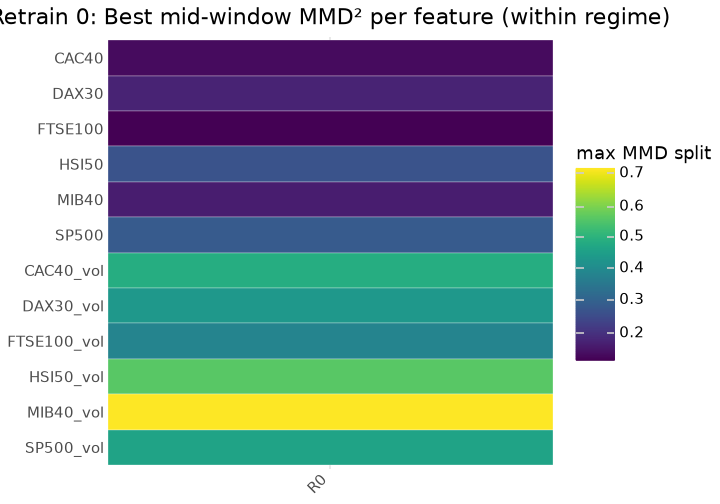

energy: d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\energy_split
mmd: d:\Code\gulfstream\outputs\notebooks\equity\graph2_scores\mmd_split


In [75]:
g2_energy_dir = run_g2(
    features_df,
    params_g2_scores,
    proc_pca,
    score_dir / "energy_split",
    "PCA · energy_split",
    plot_cols,
    max_iter=2,
    threshold=1e-6,
    score_method="energy_split",
    score={"n_splits": 5, "min_side": 10, "max_rows": 80},
)

g2_mmd_dir = run_g2(
    features_df,
    params_g2_scores,
    proc_pca,
    score_dir / "mmd_split",
    "PCA · mmd_split",
    plot_cols,
    max_iter=2,
    threshold=1e-6,
    score_method="mmd_split",
    score={"n_splits": 5, "min_side": 10, "max_rows": 80, "mmd_estimator": "linear"},
)
print("energy:", g2_energy_dir)
print("mmd:", g2_mmd_dir)


---
# Comparison

Covering, **adjusted Rand index**, and breakpoint F1 (tolerance = 10 days) against
the **PCA / PELT / MMD** baseline from Part A. Part K product runs and Part L
score picks are included when those cells were executed.


In [76]:
dates = frames.dates_series(features_df).to_list()
baseline = proc_pca
n = features_df.height

def row(label: str, res) -> dict:
    f1 = breakpoint_precision_recall_f1(baseline.bkpts, res.bkpts, tolerance=10)
    return {
        "run": label,
        "n_bkpts": len(res.bkpts),
        "bkpts": res.bkpts,
        "dates": [str(dates[b]) for b in res.bkpts],
        "covering_vs_pca": covering_metric(baseline.bkpts, res.bkpts, n),
        "ari_vs_pca": adjusted_rand_index(baseline.bkpts, res.bkpts, n),
        "f1_vs_pca": f1["f1"],
        "precision_vs_pca": f1["precision"],
        "recall_vs_pca": f1["recall"],
    }

rows = [
    row("A pca/pelt/mmd", proc_pca),
    row("B kpca", proc_kpca),
    row("C dmd", proc_dmd),
    row("D binseg", proc_binseg),
    row("D bottomup", proc_bottomup),
    row("D wbs", proc_wbs),
    row("D bocpd", proc_bocpd),
    row("E energy", proc_energy),
    row("E mmd_unbiased", proc_mmd_u),
    row("E mmd_linear", proc_mmd_lin),
    row("E hotelling_t2", proc_hotelling),
    row("E multivariate_cusum", proc_mcusum),
    row("E ks_pca", proc_ks_pca),
    row("F ess window", proc_ess),
    row("G classical kmeans", proc_ckmeans),
    row("G classical hmm", proc_chmm),
    row("G classical jump_model", proc_cjump),
    row("G classical sticky_hdp_hmm", proc_chdp),
    row("G classical garch", proc_cgarch),
    row("H kmeans dimred", proc_kmeans_dim),
    row("H hmm dimred", proc_hmm_dim),
    row("I tft dimred", proc_tft),
    row("J ica", proc_ica),
    row("J fpca", proc_fpca),
    row("J nelson_siegel", proc_ns),
    row("J dynamic_factor", proc_dfactor),
]
if "proc_unc" in globals():
    rows.append(row("K uncertainty", proc_unc))
if "proc_panel" in globals():
    rows.append(row("K panel", proc_panel))

summary = pl.DataFrame(rows)
if "score_pick_table" in globals():
    print("Part L score picks (from L.1):")
    display(score_pick_table)
summary


NameError: name 'proc_cjump' is not defined

## What to try next

- Change `START` / `END`, `N_TICKERS_PER_INDEX`, or subset `tickers`.
- Combine knobs (e.g. WBS + `hotelling_t2` + ESS).
- Classical `jump_model` / `sticky_hdp_hmm` / `garch` / `hdbscan` / `optics`.
- Curve dimred: `nelson_siegel`, `fpca`, `dynamic_factor`, or `ica`.
- TFT: raise `tft_max_epochs`, try `tft_mode="univariate"`, or use `config/graph1/graph1_tft_dimred.yaml`.
- Product: `config/graph1/graph1_export_events.yaml`, streaming / panel YAMLs.
- Graph 2 scores: `config/graph2/graph2_score_{diff,factor,energy,mmd}.yaml` — retune `retrain.threshold`.
- Raise Graph 2 `max_iter` or lower `threshold`.
